# ScamPulse AI – Telecom Scam & Spam Pattern Intelligence

Industry: Telecom / Caller Protection / AI & Data Intelligence
Company Reference: Truecaller
Data Source: FTC Do Not Call complaint records

## Problem Statement

Telecom users are continuously exposed to unwanted, spam, robocall, and potentially fraudulent calls. For a caller-identification and call-protection platform such as Truecaller, understanding how unwanted-call activity changes over time, across locations, subjects, and originating numbers is essential for improving monitoring and detection strategies.

However, large-scale consumer complaint data contains multiple dimensions such as complaint date, violation date, originating phone number, geographic location, complaint subject, and robocall status. Without systematic analysis, it is difficult for an organization to identify high-volume complaint patterns, recurring originating numbers, geographic concentrations, dominant complaint categories, and newly increasing patterns.

ScamPulse AI addresses this problem by transforming FTC Do Not Call complaint records into structured analytical intelligence. The project performs data-quality validation and cleaning, followed by exploratory analysis of temporal, geographic, subject-level, robocall, originating-number, and emerging complaint patterns. An interactive dashboard is then used to present these findings in a form that can support

# Complete Workflow

Raw FTC Complaint Data
↓
Data Profiling & Understanding
↓
Data Quality Assessment
↓
Data Preparation & Standardization
↓
Pattern Exploration & Trend Analysis
↓
Geographic & Originating-Number Intelligence
↓
Emerging Pattern Identification
↓
Interactive Business Dashboard
↓
Actionable Telecom Intelligence


In [3]:
# Workflow: Load the Python libraries used across the combined notebook.
# Pandas/NumPy support data handling, Matplotlib supports EDA charts, and re is retained from the cleaning workflow.
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt


# 1) Data Understanding

### Workflow
Load each available raw FTC daily complaint CSV → inspect each file → verify that the loaded files share the same schema → concatenate them row-wise → save the combined raw dataset.


In [5]:
data1 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep1.csv")
data1

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,3.602822e+09,2026-08-31 00:00:19,2026-08-29 11:05:00,Port Angeles,Washington,360.0,Other,Y
1,5.025242e+09,2026-08-31 00:09:10,2026-08-28 09:46:00,Citrus Heights,California,502.0,Other,Y
2,7.477393e+09,2026-08-31 00:11:36,2026-08-30 15:14:00,Lawndale,California,818.0,Dropped call or no message,Y
3,5.025242e+09,2026-08-31 00:14:21,2026-08-28 09:46:00,Citrus Heights,California,502.0,Other,Y
4,7.477393e+09,2026-08-31 00:16:41,2026-08-30 15:14:00,Lawndale,California,818.0,Dropped call or no message,Y
...,...,...,...,...,...,...,...,...
10394,8.332305e+09,2026-08-31 18:15:06,2026-08-31 12:19:42,Brecksville,Ohio,216.0,No Subject Provided,Y
10395,2.247445e+09,2026-08-31 18:21:32,2026-08-31 15:24:00,NaN,Ohio,937.0,No Subject Provided,Y
10396,9.373459e+09,2026-08-31 19:01:12,2026-08-31 18:55:54,Fairborn,Ohio,937.0,Other,N
10397,5.674406e+09,2026-08-31 20:38:55,2026-08-31 15:15:21,NaN,Ohio,419.0,No Subject Provided,N


In [6]:
data1.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [7]:
data2 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep2.csv")
data2

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,2.203997e+09,2026-09-01 00:01:07,2026-08-25 00:00:00,WALNUT creek,California,925,"Reducing your debt (credit cards, mortgage, st...",Y
1,8.778913e+09,2026-09-01 00:01:20,2026-08-31 00:00:00,Roselle,Illinois,618,"Reducing your debt (credit cards, mortgage, st...",Y
2,4.805064e+09,2026-09-01 00:02:25,2026-08-31 15:49:00,Mesa,Arizona,480,Dropped call or no message,Y
3,6.307332e+09,2026-09-01 00:03:04,2026-08-31 13:45:00,NaN,Illinois,256,Other,N
4,8.335393e+09,2026-09-01 00:03:53,2026-08-31 02:15:00,MISSOURI CITY,Texas,409,"Reducing your debt (credit cards, mortgage, st...",Y
...,...,...,...,...,...,...,...,...
10866,5.137475e+09,2026-09-01 18:07:55,2026-09-01 18:07:35,Cinti,Ohio,513,Other,Y
10867,2.503713e+09,2026-09-01 19:36:07,2026-09-01 19:35:14,NaN,Ohio,740,No Subject Provided,Y
10868,2.137998e+09,2026-09-01 19:39:29,2026-09-01 19:38:52,NaN,Ohio,614,Other,Y
10869,4.195069e+09,2026-09-01 19:43:35,2026-09-01 18:54:54,NaN,Ohio,419,No Subject Provided,N


In [8]:
data2.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [9]:
data3 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep3.csv")
data3

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,6038442374,2026-09-02 00:00:36,2026-09-01 19:28:00,Plymouth,New Hampshire,603,Other,N
1,6036979085,2026-09-02 00:01:34,2026-09-01 20:54:00,Plymouth,New Hampshire,603,No Subject Provided,N
2,5065334830,2026-09-02 00:01:42,2026-08-31 18:46:00,Tampa,Florida,785,"Calls pretending to be government, businesses,...",Y
3,8337460697,2026-09-02 00:02:18,2026-09-01 21:49:00,Fredericksburg,Virginia,240,"Reducing your debt (credit cards, mortgage, st...",Y
4,8887767016,2026-09-02 00:05:38,2026-07-30 21:34:00,Fredericksburg,Maryland,240,"Reducing your debt (credit cards, mortgage, st...",Y
...,...,...,...,...,...,...,...,...
10662,9373458461,2026-09-02 17:03:09,2026-09-02 16:51:54,Fairborn,Ohio,937,Other,N
10663,9373458480,2026-09-02 19:16:20,2026-09-02 19:11:45,Fairborn,Ohio,937,Other,N
10664,4194647914,2026-09-02 19:39:17,2026-09-02 16:11:28,NaN,Ohio,419,No Subject Provided,N
10665,4194649137,2026-09-02 19:43:50,2026-09-02 18:15:22,NaN,Ohio,419,No Subject Provided,N


In [10]:
data3.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [11]:
data4 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep4.csv")
data4

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,8.334311e+09,2026-09-03 00:05:40,2026-08-31 20:52:00,Clarksburg,Maryland,301,Other,NaN
1,5.108550e+09,2026-09-03 00:08:50,2026-09-02 14:45:00,NaN,California,510,Dropped call or no message,NaN
2,6.468835e+09,2026-09-03 00:09:35,2026-09-02 18:58:00,Stone Mountain,Georgia,470,Other,N
3,9.083128e+09,2026-09-03 00:10:14,2026-09-02 20:00:00,NaN,Alaska,907,Other,Y
4,4.022241e+09,2026-09-03 00:11:47,2026-09-01 14:20:00,Stone Mountain,Georgia,470,Other,N
...,...,...,...,...,...,...,...,...
12293,6.315004e+09,2026-09-03 23:57:44,2026-09-03 17:19:00,NaN,Utah,801,"Reducing your debt (credit cards, mortgage, st...",Y
12294,6.124051e+09,2026-09-03 23:58:32,2026-09-02 14:00:00,Faribault,Minnesota,507,"Calls pretending to be government, businesses,...",Y
12295,9.163893e+09,2026-09-03 23:58:33,2026-09-03 14:03:00,Vacaville,California,707,Other,N
12296,6.625910e+09,2026-09-03 23:59:06,2026-09-03 18:14:00,NaN,Utah,801,"Reducing your debt (credit cards, mortgage, st...",Y


In [12]:
data4.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [13]:
data5 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep7.csv")
data5

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,5075955339,2026-09-04 00:00:24,2026-09-02 14:05:00,Faribault,Minnesota,507.0,"Calls pretending to be government, businesses,...",Y
1,8336726298,2026-09-04 00:00:40,2026-09-03 18:57:00,NaN,Utah,801.0,"Reducing your debt (credit cards, mortgage, st...",Y
2,7073559600,2026-09-04 00:00:42,2026-09-03 10:07:00,Vacaville,California,707.0,Other,N
3,5142064679,2026-09-04 00:00:48,2026-09-03 13:15:00,NaN,Minnesota,763.0,"Reducing your debt (credit cards, mortgage, st...",Y
4,9163892529,2026-09-04 00:01:53,2026-09-03 09:00:00,Vacaville,California,707.0,Other,N
...,...,...,...,...,...,...,...,...
16169,9097637586,2026-09-06 23:55:13,2026-09-01 14:28:00,NaN,California,909.0,Other,NaN
16170,5597684968,2026-09-06 23:55:36,2026-09-04 14:53:00,NaN,Indiana,260.0,Dropped call or no message,N
16171,9097606739,2026-09-06 23:57:15,2026-08-31 16:04:00,NaN,California,909.0,Other,NaN
16172,9094401639,2026-09-06 23:58:18,2026-08-30 13:17:00,NaN,California,909.0,Other,NaN


In [14]:
data5.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [15]:
data6 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep8.csv")
data6

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,3.605395e+09,2026-09-07 00:00:34,2026-09-03 09:59:00,Port Angeles,Washington,360,Other,Y
1,3.602762e+09,2026-09-07 00:02:22,2026-09-04 15:07:00,Port Angeles,Washington,360,Other,Y
2,2.488838e+09,2026-09-07 00:02:28,2026-09-04 17:48:00,NaN,Michigan,248,Other,N
3,3.602766e+09,2026-09-07 00:03:45,2026-09-05 10:10:00,Port Angeles,Washington,360,Other,Y
4,2.488838e+09,2026-09-07 00:04:18,2026-09-05 16:13:00,NaN,Michigan,248,Other,NaN
...,...,...,...,...,...,...,...,...
2894,2.085654e+09,2026-09-07 23:56:52,2026-09-07 13:58:00,NaN,California,510,Dropped call or no message,NaN
2895,7.025274e+09,2026-09-07 23:58:09,2026-09-03 09:45:00,LAS VEGAS,Nevada,702,Other,NaN
2896,4.149147e+09,2026-09-07 23:58:42,2026-09-07 21:57:00,NaN,Montana,406,Other,Y
2897,7.024878e+09,2026-09-07 23:59:00,2026-09-03 10:05:00,LAS VEGAS,Nevada,702,Other,NaN


In [16]:
data6.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [17]:
data7 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep9.csv")
data7

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,7.026648e+09,2026-09-08 00:00:43,2026-09-03 10:31:00,LAS VEGAS,Nevada,702,Other,NaN
1,4.694217e+09,2026-09-08 00:00:51,2026-09-03 12:00:00,Houston,Texas,210,"Calls pretending to be government, businesses,...",N
2,7.025837e+09,2026-09-08 00:01:34,2026-09-03 12:22:00,LAS VEGAS,Nevada,702,Other,NaN
3,7.023206e+09,2026-09-08 00:03:05,2026-09-03 12:54:00,LAS VEGAS,Nevada,702,Other,NaN
4,7.027779e+09,2026-09-08 00:03:59,2026-09-03 13:00:00,LAS VEGAS,Nevada,702,Other,NaN
...,...,...,...,...,...,...,...,...
10190,8.558065e+09,2026-09-08 23:58:06,2026-09-08 09:55:00,NaN,Idaho,208,Other,Y
10191,5.019464e+09,2026-09-08 23:58:43,2026-09-04 16:41:00,Lincoln,Arkansas,479,"Calls pretending to be government, businesses,...",Y
10192,4.178516e+09,2026-09-08 23:59:27,2026-08-25 15:52:00,Shawnee,Missouri,417,Other,NaN
10193,8.336615e+09,2026-09-08 23:59:57,2026-09-08 12:27:00,NaN,Idaho,208,Other,Y


In [18]:
data7.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [19]:
data8 = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\raw\DNC_Complaint_sep10.csv")
data8

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,5.019464e+09,2026-09-09 00:00:13,2026-09-04 17:01:00,Lincoln,Arkansas,479.0,"Calls pretending to be government, businesses,...",Y
1,2.066516e+09,2026-09-09 00:00:35,2026-09-08 19:05:00,Prosser,Washington,877.0,Other,Y
2,4.175620e+09,2026-09-09 00:01:04,2026-08-26 11:36:00,Shawnee,Missouri,417.0,Other,NaN
3,8.336254e+09,2026-09-09 00:01:30,2026-09-08 12:31:00,NaN,Idaho,208.0,Other,Y
4,5.019464e+09,2026-09-09 00:01:59,2026-09-04 17:42:00,Lincoln,Arkansas,479.0,"Calls pretending to be government, businesses,...",Y
...,...,...,...,...,...,...,...,...
11178,8.778834e+09,2026-09-09 23:57:05,2026-09-09 12:46:00,Tuscaloosa,Alabama,205.0,"Calls pretending to be government, businesses,...",Y
11179,8.336727e+09,2026-09-09 23:58:39,2026-09-09 21:07:00,Sarasota,Florida,941.0,"Reducing your debt (credit cards, mortgage, st...",Y
11180,5.026610e+09,2026-09-09 23:59:40,2026-09-09 15:06:00,NaN,South Carolina,864.0,"Reducing your debt (credit cards, mortgage, st...",Y
11181,8.337754e+09,2026-09-09 23:59:47,2026-09-09 15:19:00,Tuscaloosa,Alabama,205.0,"Calls pretending to be government, businesses,...",Y


In [20]:
data8.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [21]:
#Vertically - Based on rows
combined_data = pd.concat(
    [data1, data2, data3, data4, data5, data6, data7, data8], 
    axis=0,
    ignore_index =True
)
combined_data

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,3602821928.0,2026-08-31 00:00:19,2026-08-29 11:05:00,Port Angeles,Washington,360.0,Other,Y
1,5025242144.0,2026-08-31 00:09:10,2026-08-28 09:46:00,Citrus Heights,California,502.0,Other,Y
2,7477393390.0,2026-08-31 00:11:36,2026-08-30 15:14:00,Lawndale,California,818.0,Dropped call or no message,Y
3,5025242144.0,2026-08-31 00:14:21,2026-08-28 09:46:00,Citrus Heights,California,502.0,Other,Y
4,7477393390.0,2026-08-31 00:16:41,2026-08-30 15:14:00,Lawndale,California,818.0,Dropped call or no message,Y
...,...,...,...,...,...,...,...,...
84681,8778834154.0,2026-09-09 23:57:05,2026-09-09 12:46:00,Tuscaloosa,Alabama,205.0,"Calls pretending to be government, businesses,...",Y
84682,8336726720.0,2026-09-09 23:58:39,2026-09-09 21:07:00,Sarasota,Florida,941.0,"Reducing your debt (credit cards, mortgage, st...",Y
84683,5026610090.0,2026-09-09 23:59:40,2026-09-09 15:06:00,NaN,South Carolina,864.0,"Reducing your debt (credit cards, mortgage, st...",Y
84684,8337753701.0,2026-09-09 23:59:47,2026-09-09 15:19:00,Tuscaloosa,Alabama,205.0,"Calls pretending to be government, businesses,...",Y


In [22]:
import os
print(os.getcwd())

C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\notebooks


In [23]:
combined_data.to_csv(
    r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\combined\DNC_September_2026_Combined_Raw.csv",
    index=False
)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [24]:
import os
print(os.path.exists(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\combined\DNC_September_2026_Combined_Raw.csv"
))

True


### Data Understanding Check — raw files before combination
**What we check:** confirm that all loaded daily files have data, that their column names are consistent, and that no unexpected schema difference will be introduced when they are combined.


In [26]:
# Workflow: Verify the eight loaded raw datasets before concatenation.
raw_datasets = [data1, data2, data3, data4, data5, data6, data7, data8]
raw_file_names = [
    "sep1", "sep2", "sep3", "sep4",
    "sep7", "sep8", "sep9", "sep10"
]

raw_check = pd.DataFrame({
    "File": raw_file_names,
    "Rows": [len(df) for df in raw_datasets],
    "Columns": [len(df.columns) for df in raw_datasets],
    "Empty": [df.empty for df in raw_datasets]
})

print(raw_check)
print("\nAll files use the same column order:", all(df.columns.equals(data1.columns) for df in raw_datasets))
print("Expected columns:")
print(list(data1.columns))


    File   Rows  Columns  Empty
0   sep1  10399        8  False
1   sep2  10871        8  False
2   sep3  10667        8  False
3   sep4  12298        8  False
4   sep7  16174        8  False
5   sep8   2899        8  False
6   sep9  10195        8  False
7  sep10  11183        8  False

All files use the same column order: True
Expected columns:
['Company_Phone_Number', 'Created_Date', 'Violation_Date', 'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject', 'Recorded_Message_Or_Robocall']


# 2) Data Quality

### Workflow
Load the saved combined raw dataset → inspect shape, columns, datatypes, missing values, duplicates, date ranges, categorical values, and other quality signals → record issues that cleaning must address.

**Important:** This phase checks the data; it does not perform the cleaning transformations.


In [28]:
dataset = pd.read_csv(r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\combined\DNC_September_2026_Combined_Raw.csv",
)
dataset


,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
0,3.602822e+09,2026-08-31 00:00:19,2026-08-29 11:05:00,Port Angeles,Washington,360.0,Other,Y
1,5.025242e+09,2026-08-31 00:09:10,2026-08-28 09:46:00,Citrus Heights,California,502.0,Other,Y
2,7.477393e+09,2026-08-31 00:11:36,2026-08-30 15:14:00,Lawndale,California,818.0,Dropped call or no message,Y
3,5.025242e+09,2026-08-31 00:14:21,2026-08-28 09:46:00,Citrus Heights,California,502.0,Other,Y
4,7.477393e+09,2026-08-31 00:16:41,2026-08-30 15:14:00,Lawndale,California,818.0,Dropped call or no message,Y
...,...,...,...,...,...,...,...,...
84681,8.778834e+09,2026-09-09 23:57:05,2026-09-09 12:46:00,Tuscaloosa,Alabama,205.0,"Calls pretending to be government, businesses,...",Y
84682,8.336727e+09,2026-09-09 23:58:39,2026-09-09 21:07:00,Sarasota,Florida,941.0,"Reducing your debt (credit cards, mortgage, st...",Y
84683,5.026610e+09,2026-09-09 23:59:40,2026-09-09 15:06:00,NaN,South Carolina,864.0,"Reducing your debt (credit cards, mortgage, st...",Y
84684,8.337754e+09,2026-09-09 23:59:47,2026-09-09 15:19:00,Tuscaloosa,Alabama,205.0,"Calls pretending to be government, businesses,...",Y


In [29]:
dataset.shape

(84686, 8)

In [30]:
dataset.columns

Index(['Company_Phone_Number', 'Created_Date', 'Violation_Date',
       'Consumer_City', 'Consumer_State', 'Consumer_Area_Code', 'Subject',
       'Recorded_Message_Or_Robocall'],
      dtype='object')

In [31]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84686 entries, 0 to 84685
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Company_Phone_Number          80717 non-null  float64
 1   Created_Date                  84686 non-null  object 
 2   Violation_Date                84686 non-null  object 
 3   Consumer_City                 56809 non-null  object 
 4   Consumer_State                84187 non-null  object 
 5   Consumer_Area_Code            84681 non-null  float64
 6   Subject                       84686 non-null  object 
 7   Recorded_Message_Or_Robocall  79769 non-null  object 
dtypes: float64(2), object(6)
memory usage: 5.2+ MB


In [32]:
print(dataset.isnull().sum(axis=1))

0        0
1        0
2        0
3        0
4        0
        ..
84681    0
84682    0
84683    1
84684    0
84685    1
Length: 84686, dtype: int64


In [33]:
dataset.describe(include="all")

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall
count,8.071700e+04,84686,84686,56809,84187,84681.000000,84686,79769
unique,NaN,75939,16288,7252,57,NaN,15,2
top,NaN,2026-09-02 18:25:55,2026-09-01 00:00:00,Chicago,California,NaN,Other,Y
freq,NaN,9,819,404,8767,NaN,31728,59411
mean,2.437422e+15,NaN,NaN,NaN,NaN,598.358616,NaN,NaN
std,3.524324e+17,NaN,NaN,NaN,NaN,232.920460,NaN,NaN
min,0.000000e+00,NaN,NaN,NaN,NaN,201.000000,NaN,NaN
25%,4.189930e+09,NaN,NaN,NaN,NaN,405.000000,NaN,NaN
50%,7.029414e+09,NaN,NaN,NaN,NaN,614.000000,NaN,NaN
75%,8.509521e+09,NaN,NaN,NaN,NaN,806.000000,NaN,NaN


In [34]:
dataset.isnull().sum()

Company_Phone_Number             3969
Created_Date                        0
Violation_Date                      0
Consumer_City                   27877
Consumer_State                    499
Consumer_Area_Code                  5
Subject                             0
Recorded_Message_Or_Robocall     4917
dtype: int64

In [35]:
duplicate_count = dataset.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 8


In [36]:
print("Created Date:")
print(dataset["Created_Date"].min())
print(dataset["Created_Date"].max())

print("\nViolation Date:")
print(dataset["Violation_Date"].min())
print(dataset["Violation_Date"].max())

Created Date:
2026-08-31 00:00:19
2026-09-09 23:59:47

Violation Date:
2003-11-11 12:00:00
2029-09-09 12:00:00


In [37]:
print(dataset["Recorded_Message_Or_Robocall"].unique())

['Y' 'N' nan]


### Data Quality Check — city field
**What we check:** count distinct reported cities in the raw combined dataset. The supplied city-check cell uses the name `cleaned_dataset`; the alias below keeps that existing check executable without changing its original code.


In [39]:
# Workflow: Keep the existing city quality check pointed at the raw dataset.
# No cleaning is performed here; this is only a variable alias for the supplied check.
cleaned_dataset = dataset


In [40]:
cleaned_dataset["Consumer_City"].nunique()

7252

In [41]:
cities = dataset["Consumer_City"].dropna().unique()

for city in cities:
    print(city)

Port Angeles
Citrus Heights
Lawndale
Poughkeepsie
Memphis
San Jose
Fayetteville
Hopkinsville
Port Arthur
Dauberville
Racine
Montgomery
Union Bridge
West End Alexandria, VA
SANDWICH
Clarksville
Atlanta
Caldwell
Lake Worth
Hickory
Knoxville
Mumbai
Charlottesville
Niota
PAMPLONA
Bognor Regis
GLENWOOD
Palm Bay
Smyrna
Edenton
Soblinec
La Grange
Charleston
Colorado Springs
Lake Ronkonkoma
Quantico
STOCKTON
sUNDERLAND
Clifton
Shorewood
Staunton
New York City
St. Louis
Riverview
Torrance
Middle Village
Litchfield Park
Marinette
PHOENIX
Fairbanks
Tucson
Ponca City
Patna
WAKEFIELD
Cornelius
Roanoke Rapids
CATLETTSBURG
NC
Corona
Renton
Eaton Rapids
Saint Louis
San Angelo
COLUMBUS
Fonda
CLAYTON
Brunswick
Wake Forest
Whiting
Aldie
Menifee
Westport
Ogden
Pensacola
Oak Harbor
Dawsonville
Georgetown
Jackson
Cottage Grove
Monroe
Miami
woodway
Jacksonville
ESPYVILLE
North Augusta
Hendersonville
Christiansburg
Normalville
Webster City
Elizabethtown
Boca Raton
Fairfield
Arlington
Martinsville
wichita fall

### Additional Data Quality Checks
**What we check:** identify missing-value proportions, required-column availability, parseable dates, impossible date ordering, and unexpected robocall labels before entering the cleaning stage.


In [43]:
# Workflow: Run non-destructive quality checks on the raw combined dataset.
expected_columns = [
    "Company_Phone_Number",
    "Created_Date",
    "Violation_Date",
    "Consumer_City",
    "Consumer_State",
    "Consumer_Area_Code",
    "Subject",
    "Recorded_Message_Or_Robocall"
]

print("Missing required columns:", [c for c in expected_columns if c not in dataset.columns])

missing_summary = pd.DataFrame({
    "Missing_Count": dataset[expected_columns].isna().sum(),
    "Missing_Percentage": (dataset[expected_columns].isna().mean() * 100).round(2)
})
missing_summary


Missing required columns: []


,Missing_Count,Missing_Percentage
Company_Phone_Number,3969,4.69
Created_Date,0,0.00
Violation_Date,0,0.00
Consumer_City,27877,32.92
Consumer_State,499,0.59
Consumer_Area_Code,5,0.01
Subject,0,0.00
Recorded_Message_Or_Robocall,4917,5.81


In [44]:
# Workflow: Check whether both date fields can be interpreted as dates without modifying the raw dataset.
created_check = pd.to_datetime(dataset["Created_Date"], errors="coerce")
violation_check = pd.to_datetime(dataset["Violation_Date"], errors="coerce")

print("Invalid Created_Date values:", created_check.isna().sum())
print("Invalid Violation_Date values:", violation_check.isna().sum())
print("Violation_Date later than Created_Date:", (violation_check > created_check).sum())


Invalid Created_Date values: 0
Invalid Violation_Date values: 0
Violation_Date later than Created_Date: 3864


In [45]:
# Workflow: Inspect the categorical values that will be standardized during cleaning.
print("Robocall / recorded-message values:")
print(dataset["Recorded_Message_Or_Robocall"].value_counts(dropna=False))

print("\nConsumer_State sample values:")
print(dataset["Consumer_State"].dropna().astype("string").drop_duplicates().sort_values().head(25).to_list())


Robocall / recorded-message values:
Recorded_Message_Or_Robocall
Y      59411
N      20358
NaN     4917
Name: count, dtype: int64

Consumer_State sample values:
['APO EUROPE', 'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'British Columbia, Canada', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts']


# 3) Data Cleaning

### Workflow
Use the combined dataset already loaded in Data Quality → remove exact duplicate rows → standardize dates and identifiers → handle missing / invalid values → create date-order and reporting-delay flags → validate the final dataset → save the processed CSV.


In [47]:
cleaned_dataset = dataset.copy()

In [48]:
print("Duplicate rows:", cleaned_dataset.duplicated().sum())

Duplicate rows: 8


In [49]:
cleaned_dataset = (
    cleaned_dataset
    .drop_duplicates()
    .reset_index(drop=True)
)
print("Shape after removing duplicates:", cleaned_dataset.shape)

Shape after removing duplicates: (84678, 8)


In [50]:
print(
    "Remaining duplicate rows:",
    cleaned_dataset.duplicated().sum()
)

Remaining duplicate rows: 0


In [51]:
print(cleaned_dataset.isnull().sum())

Company_Phone_Number             3969
Created_Date                        0
Violation_Date                      0
Consumer_City                   27874
Consumer_State                    499
Consumer_Area_Code                  5
Subject                             0
Recorded_Message_Or_Robocall     4916
dtype: int64


In [52]:
object_columns = cleaned_dataset.select_dtypes(
    include=["object"]
).columns

for column in object_columns:
    blank_count = (
        cleaned_dataset[column]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"{column}: {blank_count} blank values")

Created_Date: 0 blank values
Violation_Date: 0 blank values
Consumer_City: 0 blank values
Consumer_State: 0 blank values
Subject: 0 blank values
Recorded_Message_Or_Robocall: 0 blank values


In [53]:
for column in object_columns:
    cleaned_dataset[column] = (
        cleaned_dataset[column]
        .replace(r"^\s*$", pd.NA, regex=True)
    )

In [54]:
cleaned_dataset["Created_Date"] = pd.to_datetime(
    cleaned_dataset["Created_Date"],
    errors="coerce"
)

In [55]:
cleaned_dataset["Violation_Date"] = pd.to_datetime(
    cleaned_dataset["Violation_Date"],
    errors="coerce"
)

In [56]:
print(
    "Invalid Created_Date:",
    cleaned_dataset["Created_Date"].isna().sum()
)

print(
    "Invalid Violation_Date:",
    cleaned_dataset["Violation_Date"].isna().sum()
)

Invalid Created_Date: 0
Invalid Violation_Date: 0


In [57]:
print("Created Date Range:")
print(cleaned_dataset["Created_Date"].min())
print(cleaned_dataset["Created_Date"].max())

print("\nViolation Date Range:")
print(cleaned_dataset["Violation_Date"].min())
print(cleaned_dataset["Violation_Date"].max())

Created Date Range:
2026-08-31 00:00:19
2026-09-09 23:59:47

Violation Date Range:
2003-11-11 12:00:00
2029-09-09 12:00:00


In [58]:
cleaned_dataset["Invalid_Date_Order"] = (
    cleaned_dataset["Violation_Date"]
    > cleaned_dataset["Created_Date"]
)

In [59]:
print(
    cleaned_dataset["Company_Phone_Number"]
    .head(20)
)

print(
    cleaned_dataset["Company_Phone_Number"]
    .dtype
)

0     3.602822e+09
1     5.025242e+09
2     7.477393e+09
3     5.025242e+09
4     7.477393e+09
5     2.697102e+09
6     7.075317e+09
7     6.267455e+09
8     8.288102e+09
9     7.477393e+09
10    4.583004e+09
11    9.016777e+09
12    9.013039e+09
13    6.267455e+09
14    8.288102e+09
15    9.014666e+09
16             NaN
17    7.477393e+09
18    6.157428e+09
19    9.012315e+09
Name: Company_Phone_Number, dtype: float64
float64


In [60]:
# Convert phone numbers to numeric where possible
phone_numeric = pd.to_numeric(
    cleaned_dataset["Company_Phone_Number"],
    errors="coerce"
)

# Keep only valid 10-digit phone numbers
valid_phone = phone_numeric.between(
    1000000000,
    9999999999
)

# Start with missing values
cleaned_dataset["Company_Phone_Number"] = pd.Series(
    pd.NA,
    index=cleaned_dataset.index,
    dtype="string"
)

# Convert valid numbers to 10-digit strings
cleaned_dataset.loc[valid_phone, "Company_Phone_Number"] = (
    phone_numeric.loc[valid_phone]
    .round()
    .astype("int64")
    .astype("string")
)

# Represent missing/invalid phone numbers
cleaned_dataset["Company_Phone_Number"] = (
    cleaned_dataset["Company_Phone_Number"]
    .fillna("Not_Reported")
)

In [61]:
phone_length = (
    cleaned_dataset["Company_Phone_Number"]
    .str.len()
)
print(
    phone_length.value_counts(dropna=False).sort_index()
)

Company_Phone_Number
10    80014
12     4664
Name: count, dtype: Int64


In [62]:
invalid_phone = cleaned_dataset.loc[
    (cleaned_dataset["Company_Phone_Number"] != "Not_Reported") &
    (cleaned_dataset["Company_Phone_Number"].str.len() != 10),
    "Company_Phone_Number"
]
print(invalid_phone)

Series([], Name: Company_Phone_Number, dtype: string)


In [63]:
print(
    invalid_phone.astype("string").str.len().value_counts()
)

Series([], Name: count, dtype: Int64)


In [64]:
print(
    cleaned_dataset.loc[
        (cleaned_dataset["Company_Phone_Number"] != "Not_Reported") &
        (cleaned_dataset["Company_Phone_Number"].str.len() != 10),
        "Company_Phone_Number"
    ].head(100).to_list()
)

[]


In [65]:
cleaned_dataset["Company_Phone_Number"].value_counts().head(5)

Company_Phone_Number
Not_Reported    4664
3093129642       126
7754381723       123
8883102379       113
8775783941       105
Name: count, dtype: Int64

In [66]:
phone_check = cleaned_dataset.loc[
    cleaned_dataset["Company_Phone_Number"] != "Not_Reported",
    "Company_Phone_Number"
].str.len()

print(phone_check.value_counts())

Company_Phone_Number
10    80014
Name: count, dtype: Int64


In [67]:
original_phone = dataset["Company_Phone_Number"]

print(
    "Original missing:",
    original_phone.isna().sum()
)

print(
    "Original non-missing:",
    original_phone.notna().sum()
)

Original missing: 3969
Original non-missing: 80717


In [68]:
print(
    original_phone[original_phone.notna()]
    .astype("string")
    .str.len()
    .value_counts()
)

Company_Phone_Number
12    80022
11      207
13      176
9       114
14       43
3        34
10       28
5        25
15       25
21       16
4         7
16        6
22        4
17        2
6         2
8         2
20        2
7         1
18        1
Name: count, dtype: Int64


In [69]:
print(
    dataset["Company_Phone_Number"]
    .dropna()
    .head(20)
)

0     3.602822e+09
1     5.025242e+09
2     7.477393e+09
3     5.025242e+09
4     7.477393e+09
5     2.697102e+09
6     7.075317e+09
7     6.267455e+09
8     8.288102e+09
9     7.477393e+09
10    4.583004e+09
11    9.016777e+09
12    9.013039e+09
13    6.267455e+09
14    8.288102e+09
15    9.014666e+09
17    7.477393e+09
18    6.157428e+09
19    9.012315e+09
20    6.267455e+09
Name: Company_Phone_Number, dtype: float64


In [70]:
phone_str = dataset["Company_Phone_Number"].dropna().astype(str)

print(phone_str[phone_str.str.len() == 12].head(20).to_list())

['3602821928.0', '5025242144.0', '7477393390.0', '5025242144.0', '7477393390.0', '2697102217.0', '7075316646.0', '6267454550.0', '8288101795.0', '7477393390.0', '4583004032.0', '9016777473.0', '9013038936.0', '6267454550.0', '8288101795.0', '9014666367.0', '7477393390.0', '6157427855.0', '9012314994.0', '6267454550.0']


In [71]:
phone_numeric = pd.to_numeric(
    cleaned_dataset["Company_Phone_Number"],
    errors="coerce"
)

cleaned_dataset["Company_Phone_Number"] = (
    phone_numeric
    .apply(lambda x: str(int(x)) if pd.notna(x) else pd.NA)
    .astype("string")
)

In [72]:
phone_numeric = pd.to_numeric(
    dataset["Company_Phone_Number"],
    errors="coerce"
)

phone_clean_test = (
    phone_numeric
    .apply(lambda x: str(int(x)) if pd.notna(x) else pd.NA)
    .astype("string")
)

print(
    phone_clean_test.str.len()
    .value_counts(dropna=False)
)

Company_Phone_Number
10      80022
<NA>     3969
9         207
11        176
7         114
12         43
1          34
8          28
3          25
13         25
19          9
18          8
2           7
14          6
20          3
17          2
15          2
4           2
6           2
5           1
16          1
Name: count, dtype: Int64


In [73]:
invalid_phone = phone_clean_test[
    phone_clean_test.notna() &
    (phone_clean_test.str.len() != 10)
]

print(invalid_phone.head(50).to_list())

['67', '676979916', '35799916191', '836253169', '407905528', '450212230', '658603500', '95988500151', '63142365545', '866791578', '0', '502462639', '31637596290', '114632827256', '118125238871', '9039900', '80146015569', '90492020605', '7424024', '6038542808481', '706701762', '7049744', '184475023645', '215201281', '813664545', '414229868', '8652971238865658880', '203503157', '90526988416', '985304664', '0', '727674242480', '678', '610934206', '306358733', '877', '51673702', '8150666', '83333273603', '97243657711', '86664111177', '520231936252035392', '847814085', '50246231783', '0', '21886199707', '78447574399', '84444493369', '81346159009', '295483193']


In [74]:
phone_11 = phone_clean_test[
    phone_clean_test.str.len() == 11
]
print(phone_11.head(50).to_list())

['35799916191', '95988500151', '63142365545', '31637596290', '80146015569', '90492020605', '90526988416', '83333273603', '97243657711', '86664111177', '50246231783', '21886199707', '78447574399', '84444493369', '81346159009', '68134299257', '76046252432', '88788367998', '62088775905', '99498495659', '92522380064', '87222088227', '84789736209', '89472582775', '43023882489', '94154153519', '49046477537', '87723808047', '44348989502', '83098519971', '31079071676', '92838427418', '70047974251', '47098803541', '88189252712', '68262214392', '78883821222', '85638365544', '70850006330', '72522203005', '35952919816', '70747123147', '86633983636', '82834001701', '57456266198', '85061517889', '88888861787', '81322965104', '36863762796', '47930261689']


In [75]:
invalid_phone = (
    cleaned_dataset["Company_Phone_Number"].notna()
    & (cleaned_dataset["Company_Phone_Number"].str.len() != 10)
)

cleaned_dataset.loc[
    invalid_phone,
    "Company_Phone_Number"
] = "Not_Reported"

In [76]:
print(
    cleaned_dataset["Company_Phone_Number"]
    .str.len()
    .value_counts(dropna=False)
)

Company_Phone_Number
10      80014
<NA>     4664
Name: count, dtype: Int64


In [77]:
invalid_phone = (
    cleaned_dataset["Company_Phone_Number"].notna()
    &
    ~cleaned_dataset["Company_Phone_Number"].str.match(
        r"^\d{10}$",
        na=False
    )
)

print(
    "Invalid phone numbers:",
    invalid_phone.sum()
)

Invalid phone numbers: 0


In [78]:
cleaned_dataset.loc[
    invalid_phone,
    "Company_Phone_Number"
].head(20)

Series([], Name: Company_Phone_Number, dtype: string)

In [79]:
cleaned_dataset["Company_Phone_Number"] = (
    cleaned_dataset["Company_Phone_Number"]
    .fillna("Not_Reported")
)

In [80]:
area_code_numeric = pd.to_numeric(
    cleaned_dataset["Consumer_Area_Code"],
    errors="coerce"
)

cleaned_dataset["Consumer_Area_Code"] = (
    area_code_numeric
    .astype("Int64")
    .astype("string")
)

In [81]:
invalid_area_code = (
    cleaned_dataset["Consumer_Area_Code"].notna()
    &
    ~cleaned_dataset["Consumer_Area_Code"].str.match(
        r"^\d{3}$",
        na=False
    )
)

print(
    "Invalid area codes:",
    invalid_area_code.sum()
)

Invalid area codes: 0


In [82]:
cleaned_dataset["Consumer_Area_Code"] = (
    cleaned_dataset["Consumer_Area_Code"]
    .fillna("Not_Reported")
)

In [83]:
text_columns = [
    "Consumer_City",
    "Consumer_State",
    "Subject",
    "Recorded_Message_Or_Robocall"
]
print(text_columns)

['Consumer_City', 'Consumer_State', 'Subject', 'Recorded_Message_Or_Robocall']


In [84]:
for column in text_columns:
    cleaned_dataset[column] = (
        cleaned_dataset[column]
        .astype("string")
    )

In [85]:
cleaned_dataset["Consumer_City"] = (
    cleaned_dataset["Consumer_City"]
    .str.strip()
    .str.title()
)

In [86]:
cleaned_dataset["Consumer_City"] = (
    cleaned_dataset["Consumer_City"]
    .fillna("Not_Reported")
)

In [87]:
cleaned_dataset["Consumer_State"] = (
    cleaned_dataset["Consumer_State"]
    .str.strip()
    .str.title()
)

In [88]:
cleaned_dataset["Consumer_State"] = (
    cleaned_dataset["Consumer_State"]
    .fillna("Not_Reported")
)

In [89]:
cleaned_dataset["Subject"] = (
    cleaned_dataset["Subject"]
    .str.strip()
)

In [90]:
cleaned_dataset["Recorded_Message_Or_Robocall"] = (
    cleaned_dataset["Recorded_Message_Or_Robocall"]
    .str.strip()
    .str.upper()
)

In [91]:
cleaned_dataset["Recorded_Message_Or_Robocall"] = (
    cleaned_dataset["Recorded_Message_Or_Robocall"]
    .fillna("Not_Reported")
)

In [92]:
for column in [
    "Consumer_State",
    "Recorded_Message_Or_Robocall"
]:
    print(f"\n{column}")
    print(cleaned_dataset[column].value_counts(dropna=False).head(20))


Consumer_State
Consumer_State
California        8767
Florida           8373
Texas             7232
Illinois          3888
Pennsylvania      3616
Georgia           3280
Michigan          2874
New York          2821
North Carolina    2611
Ohio              2605
New Jersey        2581
Arizona           2541
Virginia          2503
Tennessee         2272
Colorado          1677
Massachusetts     1642
Wisconsin         1459
Maryland          1429
Oklahoma          1356
South Carolina    1329
Name: count, dtype: Int64

Recorded_Message_Or_Robocall
Recorded_Message_Or_Robocall
Y               59405
N               20357
Not_Reported     4916
Name: count, dtype: Int64


In [93]:
cleaned_dataset["Reporting_Delay_Days"] = (
    cleaned_dataset["Created_Date"]
    - cleaned_dataset["Violation_Date"]
).dt.days

In [94]:
print(
    cleaned_dataset["Reporting_Delay_Days"]
    .describe()
)

count    84678.000000
mean         4.712145
std         83.998526
min      -1096.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       8332.000000
Name: Reporting_Delay_Days, dtype: float64


In [95]:
print(
    "Negative reporting delays:",
    (
        cleaned_dataset["Reporting_Delay_Days"] < 0
    ).sum()
)

Negative reporting delays: 3864


In [96]:
print(
    "Final dataset shape:",
    cleaned_dataset.shape
)

Final dataset shape: (84678, 10)


In [97]:
print(
    cleaned_dataset.isnull().sum()
)

Company_Phone_Number            0
Created_Date                    0
Violation_Date                  0
Consumer_City                   0
Consumer_State                  0
Consumer_Area_Code              0
Subject                         0
Recorded_Message_Or_Robocall    0
Invalid_Date_Order              0
Reporting_Delay_Days            0
dtype: int64


In [98]:
print(
    "Remaining exact duplicates:",
    cleaned_dataset.duplicated().sum()
)

Remaining exact duplicates: 0


In [99]:
phone_counts = (
    cleaned_dataset.loc[
        cleaned_dataset["Company_Phone_Number"] != "Not_Reported",
        "Company_Phone_Number"
    ]
    .value_counts()
)

print(phone_counts.head(20))

Company_Phone_Number
3093129642    126
7754381723    123
8883102379    113
8775783941    105
3218661469     96
8336625743     94
8889120671     92
8559942145     89
8889051759     88
8889120705     86
8553572124     85
8402637620     84
8553572026     81
8775781816     79
3213958702     78
8882690263     78
8445023058     78
8445023253     77
8304319830     73
3236182844     69
Name: count, dtype: Int64


In [100]:
print(cleaned_dataset.dtypes)

Company_Phone_Number            string[python]
Created_Date                    datetime64[ns]
Violation_Date                  datetime64[ns]
Consumer_City                   string[python]
Consumer_State                  string[python]
Consumer_Area_Code              string[python]
Subject                         string[python]
Recorded_Message_Or_Robocall    string[python]
Invalid_Date_Order                        bool
Reporting_Delay_Days                     int64
dtype: object


In [101]:
cleaned_dataset.describe(include="all")

,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall,Invalid_Date_Order,Reporting_Delay_Days
count,84678,84678,84678,84678,84678,84678,84678,84678,84678,84678.000000
unique,70266,NaN,NaN,5866,58,354,15,3,2,NaN
top,Not_Reported,NaN,NaN,Not_Reported,California,813,Other,Y,False,NaN
freq,4664,NaN,NaN,27874,8767,956,31724,59405,80814,NaN
mean,NaN,2026-09-04 16:21:10.181180672,2026-08-30 15:53:42.987635456,NaN,NaN,NaN,NaN,NaN,NaN,4.712145
min,NaN,2026-08-31 00:00:19,2003-11-11 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-1096.000000
25%,NaN,2026-09-01 22:52:26.249999872,2026-09-01 04:28:15,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,2026-09-03 19:24:25.500000,2026-09-03 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,2026-09-08 08:06:39.750000128,2026-09-05 12:26:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
max,NaN,2026-09-09 23:59:47,2029-09-09 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,8332.000000


In [102]:
cleaned_dataset.to_csv(
    r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\processed\DNC_September_2026_Processed.csv",
    index=False
)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [103]:
processed_dataset = pd.read_csv(
    r"C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\data\processed\DNC_September_2026_Processed.csv"
)

print("Saved dataset shape:", processed_dataset.shape)
processed_dataset.head()

Saved dataset shape: (84678, 10)


,Company_Phone_Number,Created_Date,Violation_Date,Consumer_City,Consumer_State,Consumer_Area_Code,Subject,Recorded_Message_Or_Robocall,Invalid_Date_Order,Reporting_Delay_Days
0,3602821928,2026-08-31 00:00:19,2026-08-29 11:05:00,Port Angeles,Washington,360,Other,Y,False,1
1,5025242144,2026-08-31 00:09:10,2026-08-28 09:46:00,Citrus Heights,California,502,Other,Y,False,2
2,7477393390,2026-08-31 00:11:36,2026-08-30 15:14:00,Lawndale,California,818,Dropped call or no message,Y,False,0
3,5025242144,2026-08-31 00:14:21,2026-08-28 09:46:00,Citrus Heights,California,502,Other,Y,False,2
4,7477393390,2026-08-31 00:16:41,2026-08-30 15:14:00,Lawndale,California,818,Dropped call or no message,Y,False,0


# 4) Exploratory Data Analysis (EDA)

### Workflow
Use the cleaned dataset produced above → summarize the dataset → analyze when complaints occur → analyze complaint subjects and robocall status → examine geographic and originating-number concentrations → examine reporting delays → compare recent vs previous periods for emerging patterns → summarize the findings.

### EDA principle
For every plot, the notebook states **what is being analyzed and why** so the visualization has a clear analytical purpose rather than being only a chart.


In [105]:
print("Columns:")
for column in cleaned_dataset.columns:
    print("-", column)

Columns:
- Company_Phone_Number
- Created_Date
- Violation_Date
- Consumer_City
- Consumer_State
- Consumer_Area_Code
- Subject
- Recorded_Message_Or_Robocall
- Invalid_Date_Order
- Reporting_Delay_Days


In [106]:
print(cleaned_dataset[["Created_Date", "Violation_Date"]].dtypes)

Created_Date      datetime64[ns]
Violation_Date    datetime64[ns]
dtype: object


### Dataset Overview

**Analysis objective:** Establish the scale and basic coverage of the cleaned dataset before drilling into individual complaint patterns.


In [109]:
total_complaints = len(cleaned_dataset)

unique_subjects = cleaned_dataset["Subject"].nunique()

unique_states = cleaned_dataset[
    cleaned_dataset["Consumer_State"] != "Not_Reported"
]["Consumer_State"].nunique()

unique_cities = cleaned_dataset[
    cleaned_dataset["Consumer_City"] != "Not_Reported"
]["Consumer_City"].nunique()

reported_phone_numbers = cleaned_dataset[
    cleaned_dataset["Company_Phone_Number"] != "Not_Reported"
]["Company_Phone_Number"].nunique()

robocall_reports = (
    cleaned_dataset["Recorded_Message_Or_Robocall"] == "Y"
).sum()

print("Total Complaints:", total_complaints)
print("Unique Subjects:", unique_subjects)
print("Unique States:", unique_states)
print("Unique Cities:", unique_cities)
print("Unique Reported Phone Numbers:", reported_phone_numbers)
print("Robocall Reports:", robocall_reports)

Total Complaints: 84678
Unique Subjects: 15
Unique States: 57
Unique Cities: 5865
Unique Reported Phone Numbers: 70265
Robocall Reports: 59405


### Daily Complaint Counts

**Analysis objective:** Create the daily aggregation that will be used to quantify temporal complaint activity.


In [112]:
daily_complaints = (
    cleaned_dataset
    .groupby(cleaned_dataset["Created_Date"].dt.date)
    .size()
)
print(daily_complaints)

Created_Date
2026-08-31    10399
2026-09-01    10871
2026-09-02    10667
2026-09-03    12296
2026-09-04    10915
2026-09-05     3629
2026-09-06     1628
2026-09-07     2899
2026-09-08    10192
2026-09-09    11182
dtype: int64


### Daily Complaint Volume

**Analysis objective:** Analyze complaint volume across Created_Date to identify high-activity days, spikes, drops, and the overall reporting pattern.


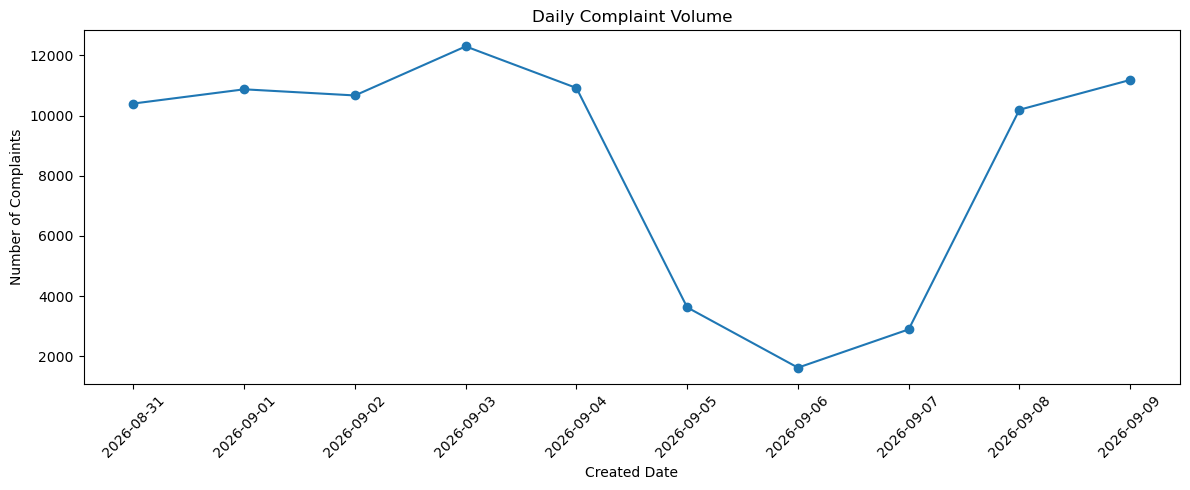

In [114]:
plt.figure(figsize=(12, 5))
plt.plot(
    daily_complaints.index,
    daily_complaints.values,
    marker="o"
)
plt.title("Daily Complaint Volume")
plt.xlabel("Created Date")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Daily Percentage-Change Table

**Analysis objective:** Create a numerical view of day-to-day complaint changes so unusually large movements can be identified alongside the plot.


In [116]:
daily_percentage_change = (
    daily_complaints
    .pct_change() * 100
)

daily_change_df = pd.DataFrame({
    "Complaint_Count": daily_complaints,
    "Percentage_Change": daily_percentage_change
})

daily_change_df

,Complaint_Count,Percentage_Change
Created_Date,,
2026-08-31,10399,NaN
2026-09-01,10871,4.538898
2026-09-02,10667,-1.876552
2026-09-03,12296,15.271398
2026-09-04,10915,-11.231295
2026-09-05,3629,-66.752176
2026-09-06,1628,-55.139157
2026-09-07,2899,78.071253
2026-09-08,10192,251.569507


### Daily Change in Complaint Volume

**Analysis objective:** Measure the percentage change from one day to the next to detect sharp increases or decreases in complaint activity.


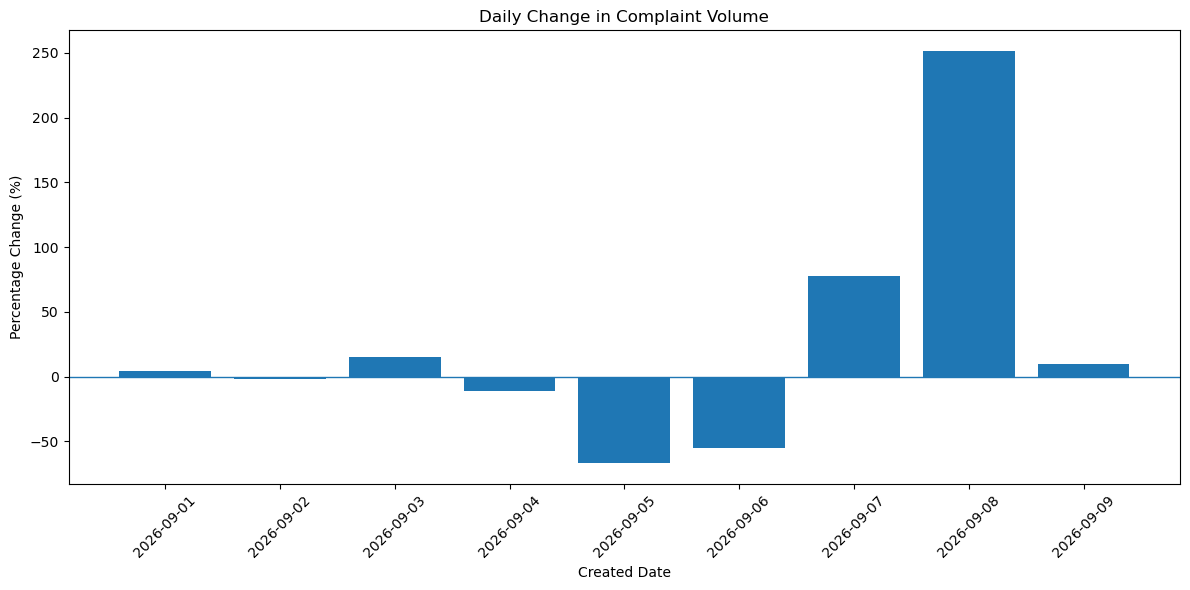

In [118]:
plt.figure(figsize=(12, 6))

plt.bar(
    daily_change_df.index,
    daily_change_df["Percentage_Change"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Daily Change in Complaint Volume")
plt.xlabel("Created Date")
plt.ylabel("Percentage Change (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 3-Day Rolling Average

**Analysis objective:** Smooth short-term daily fluctuations so the underlying complaint trend is easier to observe.


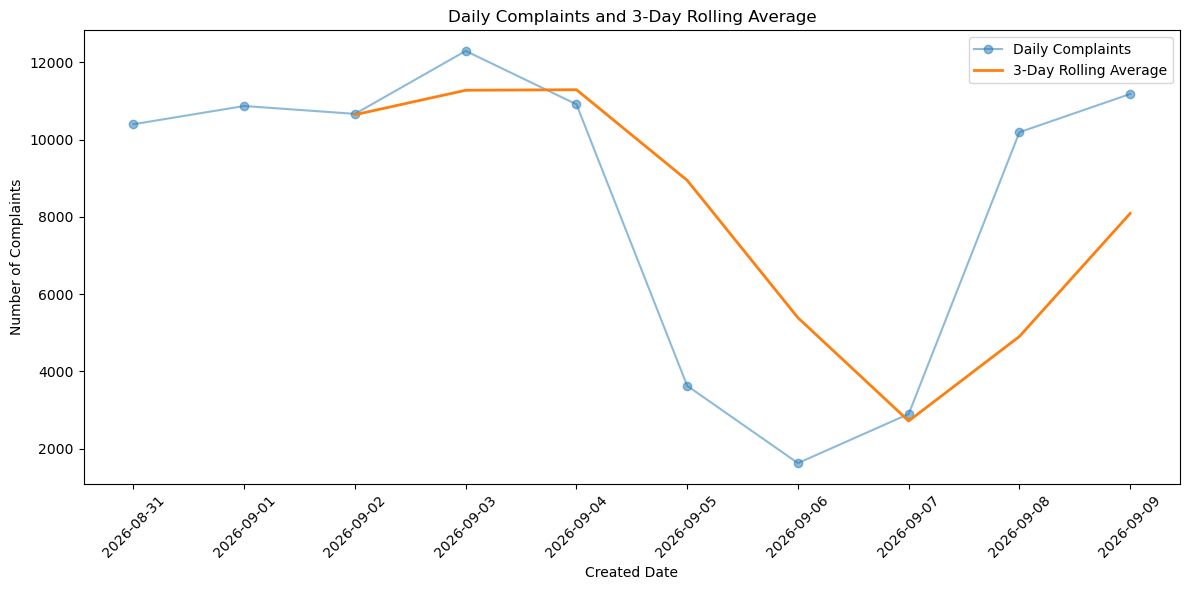

In [120]:
rolling_3_day = daily_complaints.rolling(
    window=3
).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    daily_complaints.index,
    daily_complaints.values,
    marker="o",
    alpha=0.5,
    label="Daily Complaints"
)

plt.plot(
    rolling_3_day.index,
    rolling_3_day.values,
    linewidth=2,
    label="3-Day Rolling Average"
)

plt.title("Daily Complaints and 3-Day Rolling Average")
plt.xlabel("Created Date")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### Hourly Complaint Counts

**Analysis objective:** Build the hourly aggregation needed to inspect intraday complaint concentration.


In [123]:
cleaned_dataset["Created_Hour"] = (
    cleaned_dataset["Created_Date"].dt.hour
)

hourly_complaints = (
    cleaned_dataset["Created_Hour"]
    .value_counts()
    .sort_index()
)

print(hourly_complaints)

Created_Hour
0      614
1      309
2      316
3      125
4      132
5      196
6      308
7      537
8     1017
9     2967
10    5456
11    6758
12    7580
13    7356
14    7169
15    7459
16    7891
17    7265
18    6452
19    5489
20    3871
21    2677
22    1724
23    1010
Name: count, dtype: int64


### Complaint Activity by Hour

**Analysis objective:** Analyze the hour of day when complaint records were created to identify concentration in time-of-day activity.


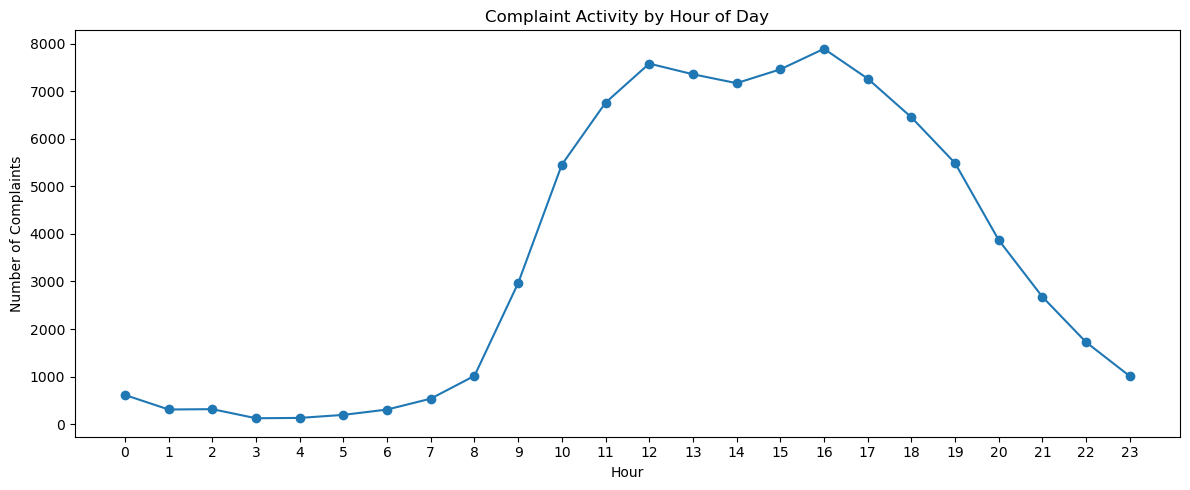

In [125]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_complaints.index,
    hourly_complaints.values,
    marker="o"
)

plt.title("Complaint Activity by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Complaints")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Day-of-Week Counts

**Analysis objective:** Build an ordered weekday summary for comparing complaint activity across the week.


In [127]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

cleaned_dataset["Created_Day"] = (
    cleaned_dataset["Created_Date"].dt.day_name()
)

day_of_week = (
    cleaned_dataset["Created_Day"]
    .value_counts()
    .reindex(day_order)
)

print(day_of_week)

Created_Day
Monday       13298
Tuesday      21063
Wednesday    21849
Thursday     12296
Friday       10915
Saturday      3629
Sunday        1628
Name: count, dtype: int64


### Complaints by Day of Week

**Analysis objective:** Compare complaint activity across weekdays and weekends to identify recurring weekly patterns.


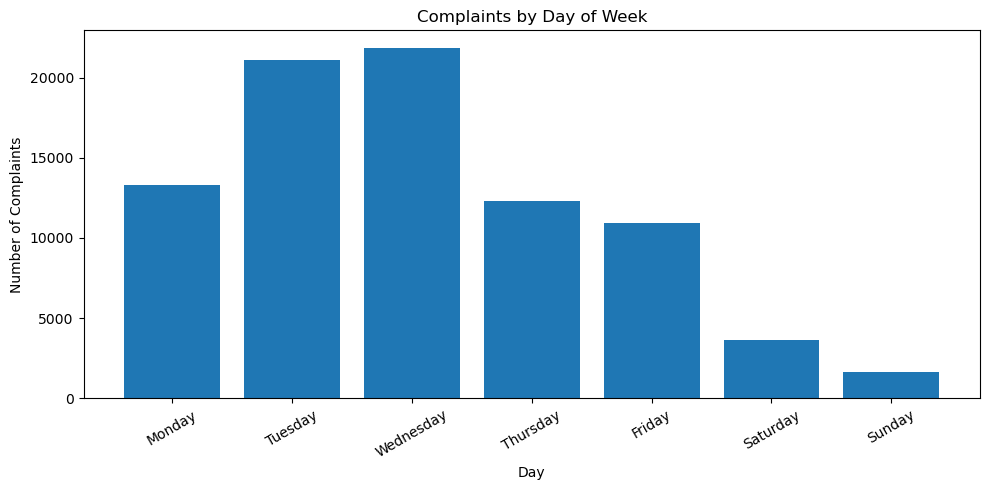

In [129]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_of_week.index,
    day_of_week.values
)

plt.title("Complaints by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Complaint Subject Counts

**Analysis objective:** Quantify the number of reports associated with each complaint subject before selecting the leading subjects for visualization.


In [132]:
subject_counts = (
    cleaned_dataset["Subject"]
    .value_counts()
)
print(subject_counts)

Subject
Other                                                                   31724
Reducing your debt (credit cards, mortgage, student loans)              21465
Calls pretending to be government, businesses, or family and friends     9819
Dropped call or no message                                               6526
No Subject Provided                                                      5565
Medical  & prescriptions                                                 5153
Warranties  & protection plans                                           1126
Home improvement  & cleaning                                             1019
Vacation  & timeshares                                                    509
Lotteries, prizes  & sweepstakes                                          466
Energy, solar,  & utilities                                               423
Computer  & technical support                                             325
Home security  & alarms                                 

### Top Complaint Subjects

**Analysis objective:** Identify which complaint topics contribute the largest number of consumer reports.


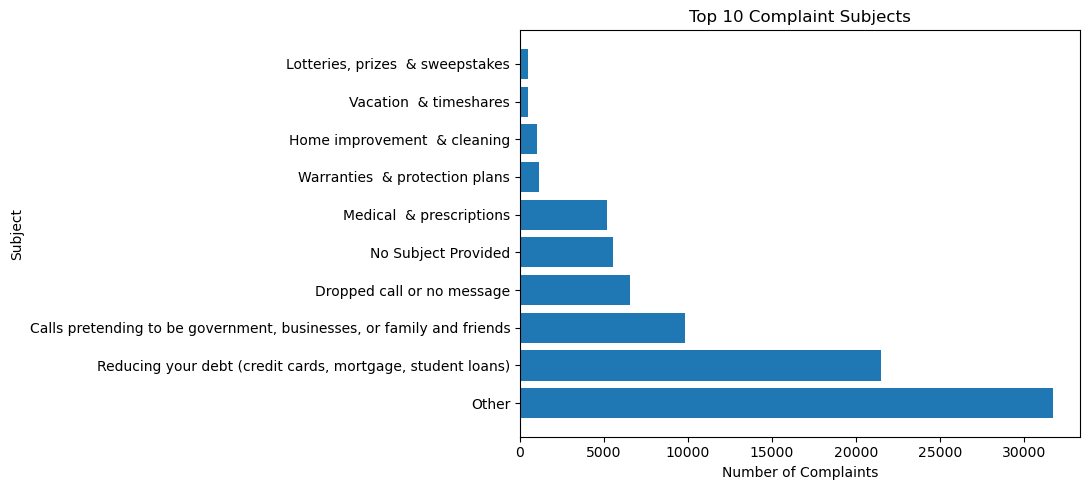

In [356]:
top_subjects = subject_counts.head(10).sort_values()

plt.figure(figsize=(11, 5))

plt.barh(
    top_subjects.index[::-1],
    top_subjects.values[::-1]
)

plt.title("Top 10 Complaint Subjects")
plt.xlabel("Number of Complaints")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

### Subject Share Summary

**Analysis objective:** Convert subject counts into percentages to understand each subject's contribution to the overall complaint volume.


In [136]:
subject_percentage = (
    subject_counts /
    len(cleaned_dataset) *
    100
)

subject_summary = pd.DataFrame({
    "Complaint_Count": subject_counts,
    "Percentage": subject_percentage.round(2)
})

subject_summary

,Complaint_Count,Percentage
Subject,,
Other,31724,37.46
"Reducing your debt (credit cards, mortgage, student loans)",21465,25.35
"Calls pretending to be government, businesses, or family and friends",9819,11.6
Dropped call or no message,6526,7.71
No Subject Provided,5565,6.57
Medical & prescriptions,5153,6.09
Warranties & protection plans,1126,1.33
Home improvement & cleaning,1019,1.2
Vacation & timeshares,509,0.6


### Top Complaint Subjects by Percentage

**Analysis objective:** Measure the share of total complaints represented by the leading subjects for easier comparison of relative importance.


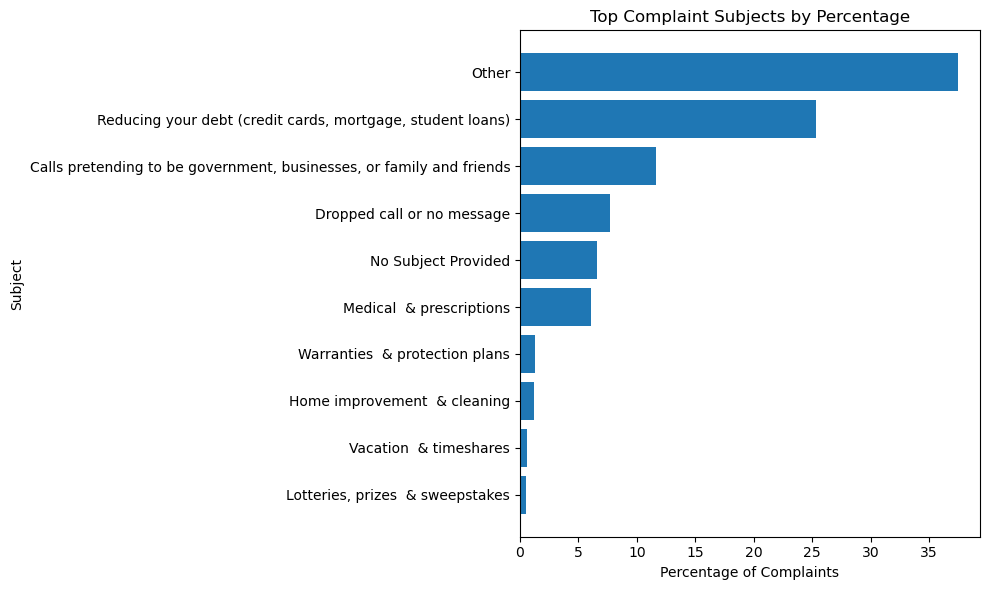

In [138]:
plt.figure(figsize=(10, 6))

plt.barh(
    subject_percentage.head(10).index[::-1],
    subject_percentage.head(10).values[::-1]
)

plt.title("Top Complaint Subjects by Percentage")
plt.xlabel("Percentage of Complaints")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

### Robocall Counts

**Analysis objective:** Establish the distribution of robocall / recorded-message status before examining the time trend.


In [141]:
robocall_counts = (
    cleaned_dataset["Recorded_Message_Or_Robocall"]
    .value_counts()
    .reindex(
        ["Y", "N", "Not_Reported"],
        fill_value=0
    )
)

print(robocall_counts)

Recorded_Message_Or_Robocall
Y               59405
N               20357
Not_Reported     4916
Name: count, dtype: Int64


### Robocall / Recorded Message Pattern

**Analysis objective:** Measure how many complaints are marked as robocalls, non-robocalls, or not reported.


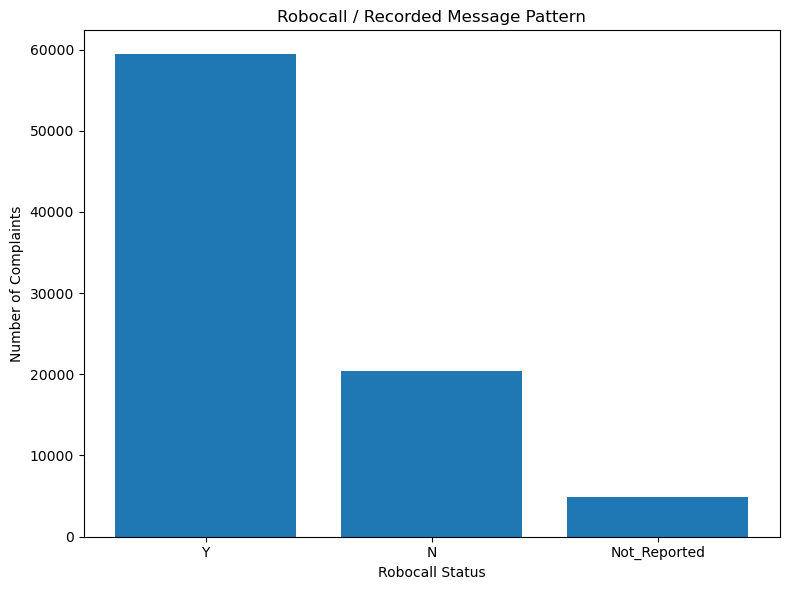

In [143]:
plt.figure(figsize=(8, 6))

plt.bar(
    robocall_counts.index,
    robocall_counts.values
)

plt.title("Robocall / Recorded Message Pattern")
plt.xlabel("Robocall Status")
plt.ylabel("Number of Complaints")

plt.tight_layout()
plt.show()

### Daily Robocall Counts

**Analysis objective:** Prepare daily robocall-status counts for temporal comparison.


In [145]:
daily_robocall = pd.crosstab(
    cleaned_dataset["Created_Date"].dt.date,
    cleaned_dataset["Recorded_Message_Or_Robocall"]
)

daily_robocall = daily_robocall.reindex(
    columns=["Y", "N", "Not_Reported"],
    fill_value=0
)

daily_robocall.head()

Recorded_Message_Or_Robocall,Y,N,Not_Reported
Created_Date,,,
2026-08-31,7418,2456,525
2026-09-01,7319,2789,763
2026-09-02,7457,2610,600
2026-09-03,8731,2783,782
2026-09-04,7746,2632,537


### Daily Robocall / Recorded Message Trend

**Analysis objective:** Track robocall status over time to see whether recorded-message complaints rise, fall, or remain stable.


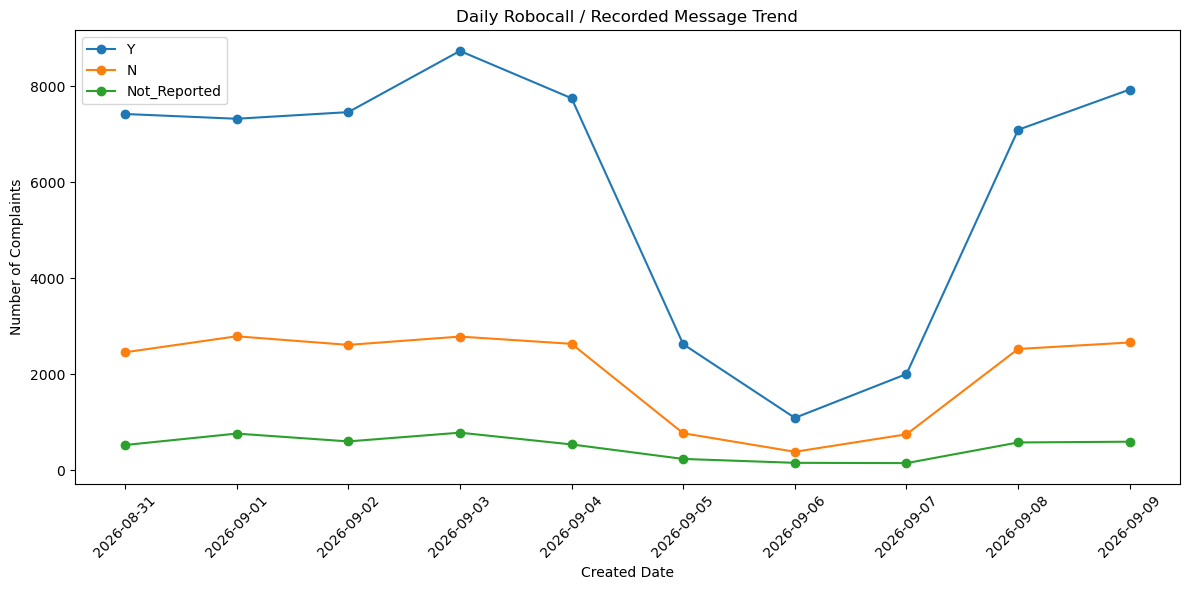

In [147]:
plt.figure(figsize=(12, 6))

for column in daily_robocall.columns:
    plt.plot(
        daily_robocall.index,
        daily_robocall[column],
        marker="o",
        label=column
    )

plt.title("Daily Robocall / Recorded Message Trend")
plt.xlabel("Created Date")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### Subject × Robocall Table

**Analysis objective:** Cross-tabulate the leading complaint subjects against robocall status to reveal combined patterns.


In [150]:
top_10_subject_names = subject_counts.head(10).index

subject_robocall = pd.crosstab(
    cleaned_dataset["Subject"],
    cleaned_dataset["Recorded_Message_Or_Robocall"]
)

subject_robocall = subject_robocall.loc[
    top_10_subject_names
]

subject_robocall = subject_robocall.reindex(
    columns=["Y", "N", "Not_Reported"],
    fill_value=0
)

subject_robocall

Recorded_Message_Or_Robocall,Y,N,Not_Reported
Subject,,,
Other,20954,8977,1793
"Reducing your debt (credit cards, mortgage, student loans)",19338,1884,243
"Calls pretending to be government, businesses, or family and friends",6501,3225,93
Dropped call or no message,3659,2230,637
No Subject Provided,2849,687,2029
Medical & prescriptions,4036,1057,60
Warranties & protection plans,660,446,20
Home improvement & cleaning,369,632,18
Vacation & timeshares,271,233,5


### Top Complaint Subjects by Robocall Status

**Analysis objective:** Analyze whether the most common complaint subjects are associated more often with robocall reports or non-robocall reports.


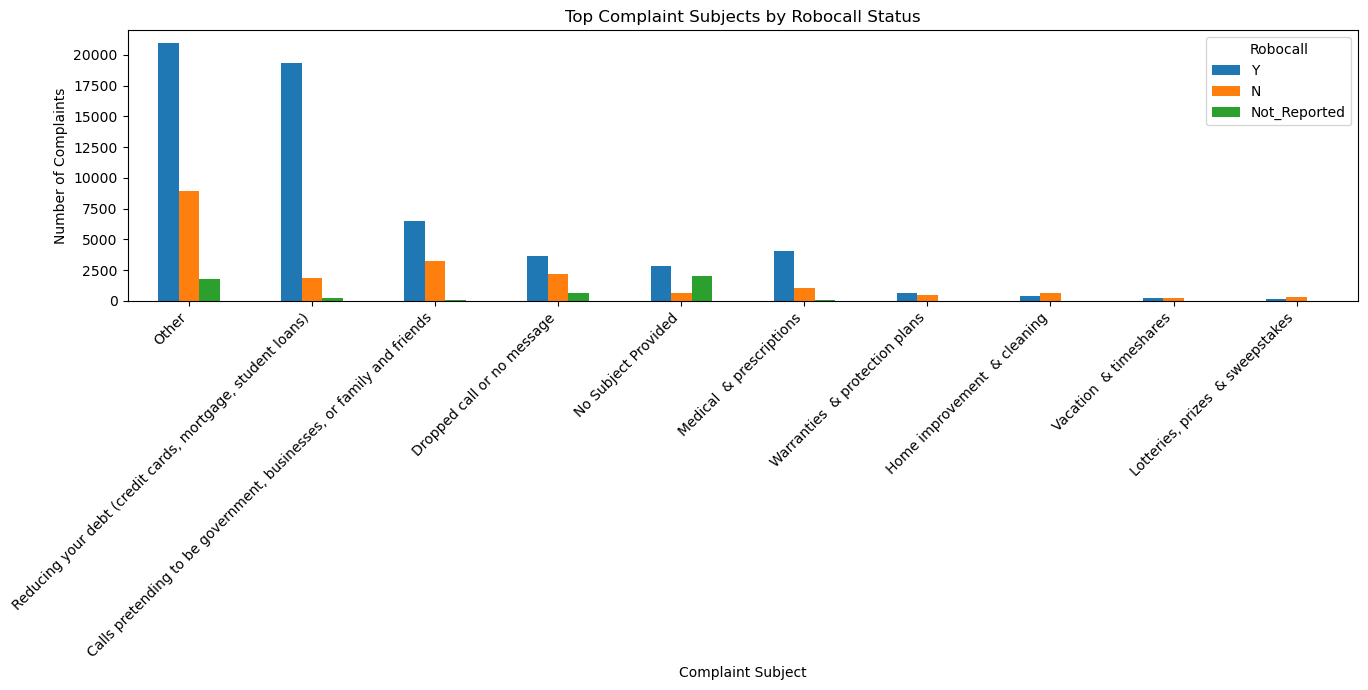

In [152]:
subject_robocall.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Top Complaint Subjects by Robocall Status")
plt.xlabel("Complaint Subject")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Robocall")

plt.tight_layout()
plt.show()

### State Complaint Counts

**Analysis objective:** Rank states by complaint volume so the geographic concentration analysis focuses on the highest-volume locations.


In [155]:
state_counts = (
    cleaned_dataset[
        cleaned_dataset["Consumer_State"] != "Not_Reported"
    ]["Consumer_State"]
    .value_counts()
)

print(state_counts.head(20))

Consumer_State
California        8767
Florida           8373
Texas             7232
Illinois          3888
Pennsylvania      3616
Georgia           3280
Michigan          2874
New York          2821
North Carolina    2611
Ohio              2605
New Jersey        2581
Arizona           2541
Virginia          2503
Tennessee         2272
Colorado          1677
Massachusetts     1642
Wisconsin         1459
Maryland          1429
Oklahoma          1356
South Carolina    1329
Name: count, dtype: Int64


### Top States by Complaint Volume

**Analysis objective:** Identify geographic concentrations at the state level and prioritize locations with higher complaint volume.


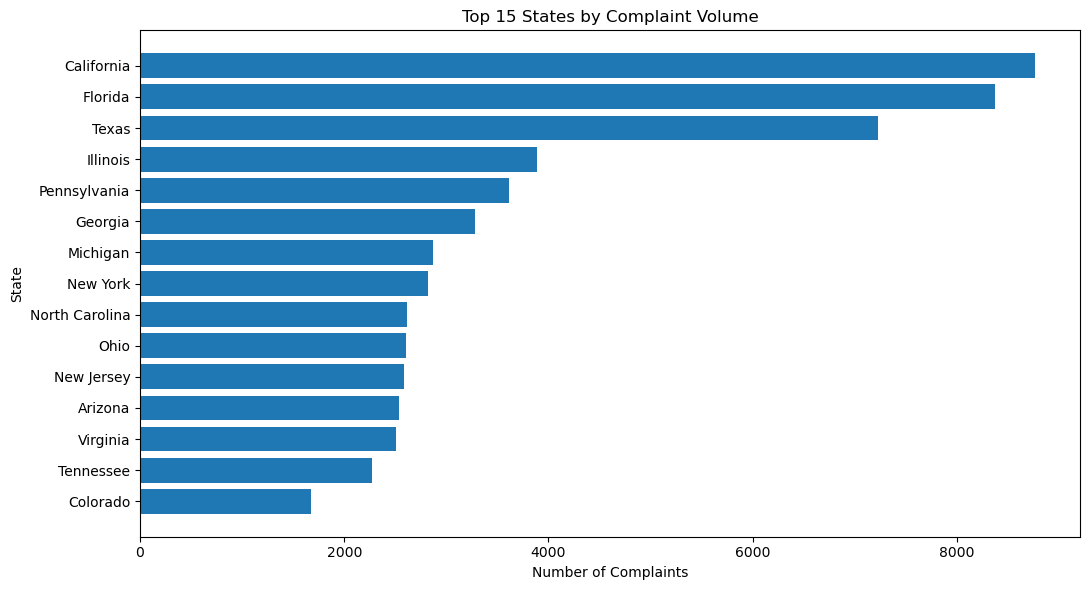

In [362]:
top_states = state_counts.head(15).sort_values()

plt.figure(figsize=(11, 6))

plt.barh(
    top_states.index,
    top_states.values
)

plt.title("Top 15 States by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### State × Robocall Table

**Analysis objective:** Cross-tabulate top states against robocall status to compare geographic and robocall behavior together.


In [159]:
top_state_names = state_counts.head(10).index

state_robocall = pd.crosstab(
    cleaned_dataset["Consumer_State"],
    cleaned_dataset["Recorded_Message_Or_Robocall"]
)

state_robocall = state_robocall.loc[
    top_state_names
]

state_robocall = state_robocall.reindex(
    columns=["Y", "N", "Not_Reported"],
    fill_value=0
)

state_robocall

Recorded_Message_Or_Robocall,Y,N,Not_Reported
Consumer_State,,,
California,5762,2498,507
Florida,6158,1756,459
Texas,5004,1679,549
Illinois,2834,723,331
Pennsylvania,2449,918,249
Georgia,2474,716,90
Michigan,1993,679,202
New York,1933,754,134
North Carolina,1845,636,130


### Top States by Robocall Status

**Analysis objective:** Compare robocall and non-robocall complaint patterns across the highest-volume states.


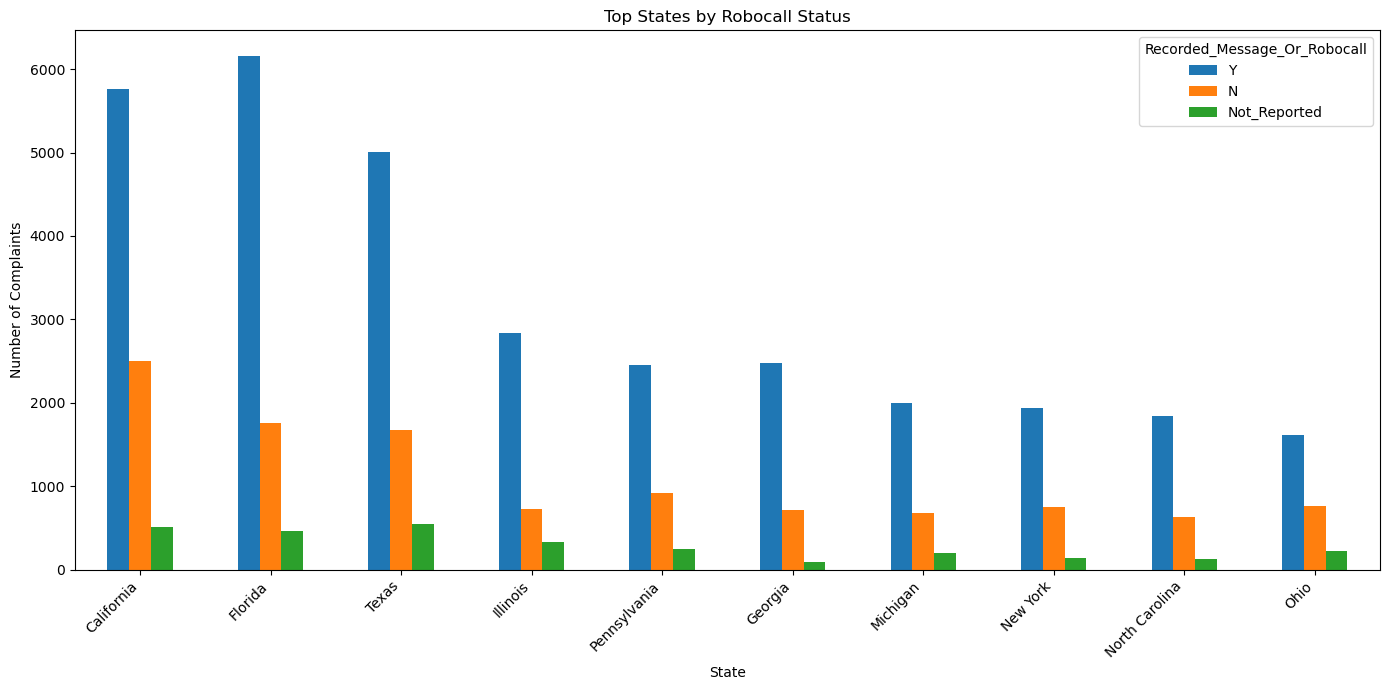

In [161]:
state_robocall.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Top States by Robocall Status")
plt.xlabel("State")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### City Complaint Counts

**Analysis objective:** Rank cities by complaint volume to identify localized hotspots within the broader state-level picture.


In [163]:
city_counts = (
    cleaned_dataset[
        cleaned_dataset["Consumer_City"] != "Not_Reported"
    ]["Consumer_City"]
    .value_counts()
)

print(city_counts.head(15))

Consumer_City
Chicago          456
Phoenix          386
Las Vegas        383
Oklahoma City    337
Houston          293
Austin           271
Miami            264
Atlanta          260
San Antonio      235
Los Angeles      232
Lexington        231
Omaha            229
Madison          225
Sacramento       222
Philadelphia     220
Name: count, dtype: Int64


### Top Cities by Complaint Volume

**Analysis objective:** Identify cities with the highest complaint counts to reveal more localized geographic concentrations.


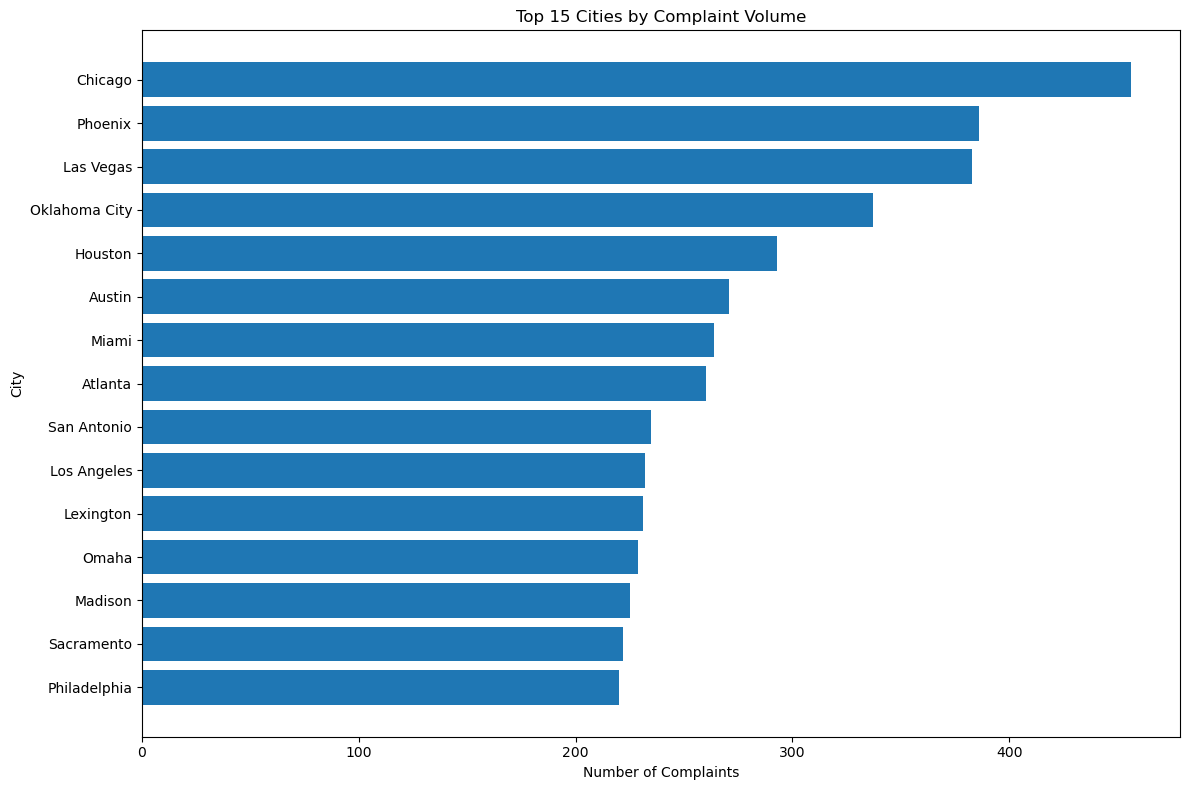

In [165]:
top_cities = city_counts.head(15).sort_values()

plt.figure(figsize=(12, 8))

plt.barh(
    top_cities.index,
    top_cities.values
)

plt.title("Top 15 Cities by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Area-Code Complaint Counts

**Analysis objective:** Rank consumer area codes to identify additional geographic concentration signals.


In [167]:
area_code_counts = (
    cleaned_dataset[
        cleaned_dataset["Consumer_Area_Code"] != "Not_Reported"
    ]["Consumer_Area_Code"]
    .value_counts()
)

print(area_code_counts.head(15))

Consumer_Area_Code
813    956
404    888
214    852
702    822
402    809
954    777
310    727
480    717
770    692
602    688
727    665
407    663
904    658
405    657
630    648
Name: count, dtype: Int64


### Top Consumer Area Codes

**Analysis objective:** Analyze area-code-level concentration as a finer geographic signal than state or city.


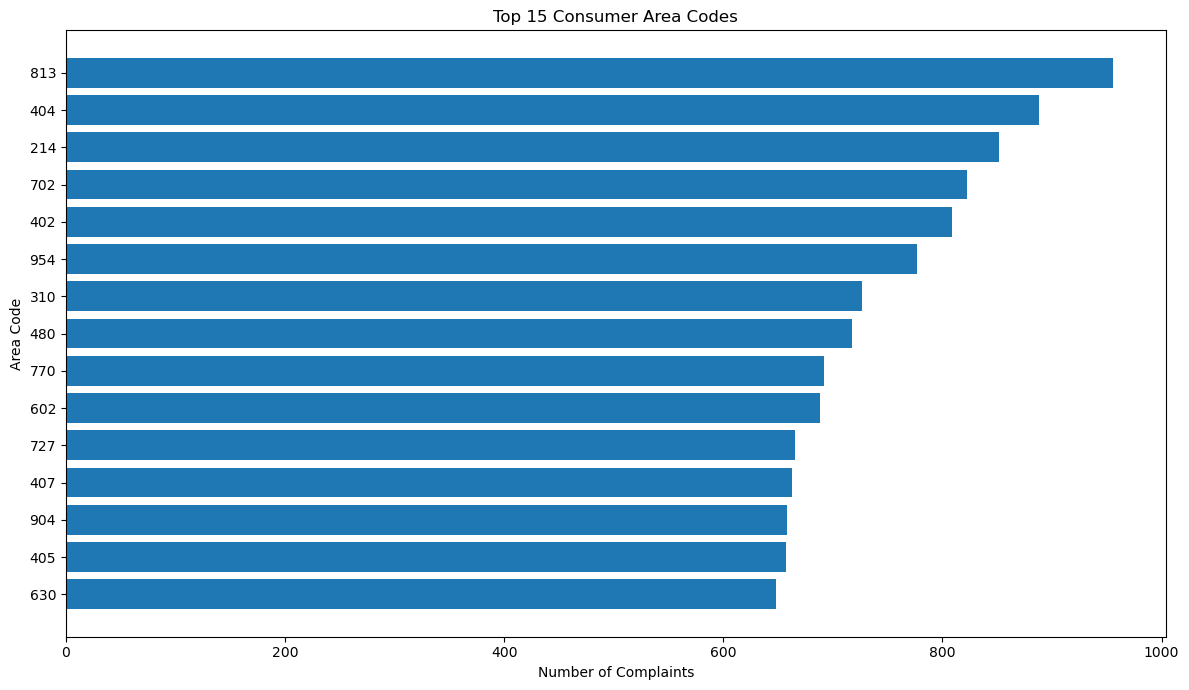

In [169]:
top_area_codes = area_code_counts.head(15).sort_values()

plt.figure(figsize=(12, 7))

plt.barh(
    top_area_codes.index.astype(str),
    top_area_codes.values
)

plt.title("Top 15 Consumer Area Codes")
plt.xlabel("Number of Complaints")
plt.ylabel("Area Code")

plt.tight_layout()
plt.show()

### Frequently Reported Number Counts

**Analysis objective:** Count repeated originating numbers to identify recurrence patterns in complaint reports.


In [171]:
phone_counts = (
    cleaned_dataset[
        cleaned_dataset["Company_Phone_Number"] != "Not_Reported"
    ]["Company_Phone_Number"]
    .value_counts()
)

print("Distinct Reported Phone Numbers:", len(phone_counts))

print(
    "Numbers Reported More Than Once:",
    (phone_counts > 1).sum()
)

print("\nTop Repeated Numbers:")
print(phone_counts.head(15))

Distinct Reported Phone Numbers: 70265
Numbers Reported More Than Once: 4767

Top Repeated Numbers:
Company_Phone_Number
3093129642    126
7754381723    123
8883102379    113
8775783941    105
3218661469     96
8336625743     94
8889120671     92
8559942145     89
8889051759     88
8889120705     86
8553572124     85
8402637620     84
8553572026     81
8775781816     79
3213958702     78
Name: count, dtype: Int64


### Frequently Reported Originating Numbers

**Analysis objective:** Identify originating phone numbers that appear repeatedly in consumer complaint records; repeated reporting indicates recurrence, not proof that a number is fraudulent.


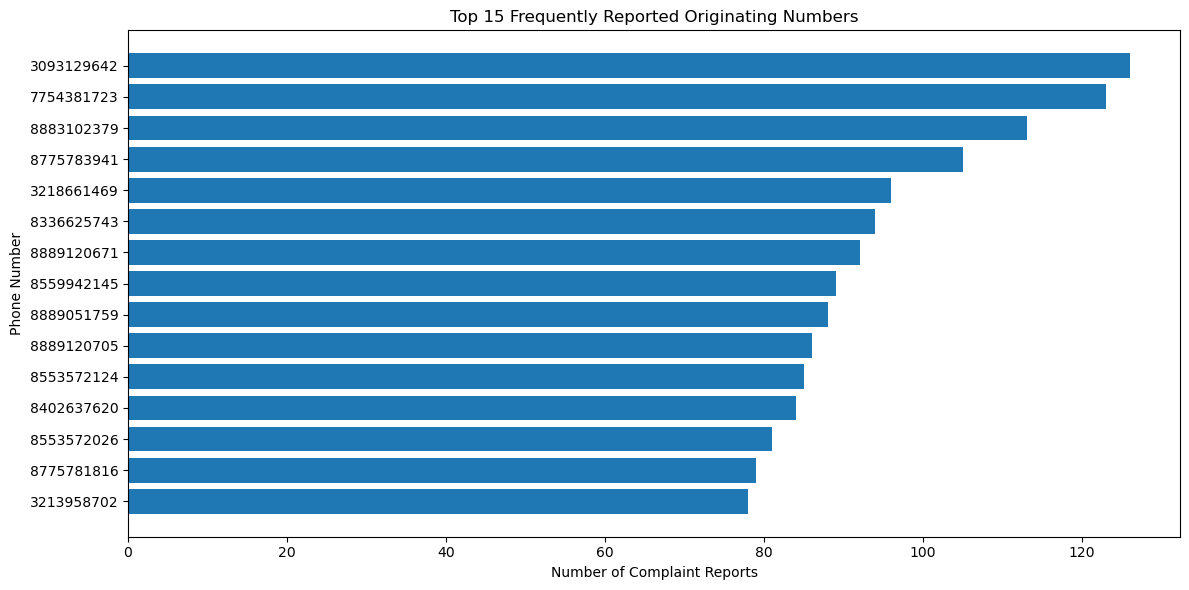

In [364]:
top_phone_numbers = phone_counts.head(15).sort_values()

plt.figure(figsize=(12, 6))

plt.barh(
    top_phone_numbers.index.astype(str),
    top_phone_numbers.values
)

plt.title("Top 15 Frequently Reported Originating Numbers")
plt.xlabel("Number of Complaint Reports")
plt.ylabel("Phone Number")

plt.tight_layout()
plt.show()

### Phone Number × Subject Analysis

**Analysis objective:** Determine whether frequently reported originating numbers are associated with one dominant complaint subject or multiple subjects.


In [175]:
repeated_phones = phone_counts[
    phone_counts > 1
].head(15).index

phone_subject_analysis = (
    cleaned_dataset[
        cleaned_dataset["Company_Phone_Number"].isin(repeated_phones)
    ]
    .groupby(
        ["Company_Phone_Number", "Subject"]
    )
    .size()
    .reset_index(name="Complaint_Count")
    .sort_values(
        "Complaint_Count",
        ascending=False
    )
)

phone_subject_analysis.head(30)

,Company_Phone_Number,Subject,Complaint_Count
42,8775783941,"Reducing your debt (credit cards, mortgage, st...",78
46,8883102379,"Reducing your debt (credit cards, mortgage, st...",78
3,3093129642,"Reducing your debt (credit cards, mortgage, st...",74
54,8889120671,"Reducing your debt (credit cards, mortgage, st...",70
18,8336625743,"Reducing your debt (credit cards, mortgage, st...",70
34,8559942145,"Reducing your debt (credit cards, mortgage, st...",65
58,8889120705,"Reducing your debt (credit cards, mortgage, st...",60
11,3218661469,"Reducing your debt (credit cards, mortgage, st...",58
26,8553572026,"Reducing your debt (credit cards, mortgage, st...",57
50,8889051759,"Reducing your debt (credit cards, mortgage, st...",55


### State × Subject Table

**Analysis objective:** Compare the most common complaint subjects across the highest-volume states.


In [177]:
top_5_subject_names = subject_counts.head(5).index
top_10_state_names = state_counts.head(10).index

state_subject = pd.crosstab(
    cleaned_dataset["Consumer_State"],
    cleaned_dataset["Subject"]
)

state_subject = state_subject.loc[
    top_10_state_names,
    top_5_subject_names
]

state_subject

Subject,Other,"Reducing your debt (credit cards, mortgage, student loans)","Calls pretending to be government, businesses, or family and friends",Dropped call or no message,No Subject Provided
Consumer_State,,,,,
California,3240,2589,1007,817,509
Florida,3035,2014,1235,457,674
Texas,2849,1267,893,476,587
Illinois,1476,1168,376,360,276
Pennsylvania,1394,845,334,219,321
Georgia,1293,1078,311,220,90
Michigan,1000,798,374,154,208
New York,941,984,332,193,183
North Carolina,1009,675,264,174,151


### Top Complaint Subjects Across Top States

**Analysis objective:** Examine how the most common complaint subjects vary across the highest-volume states.


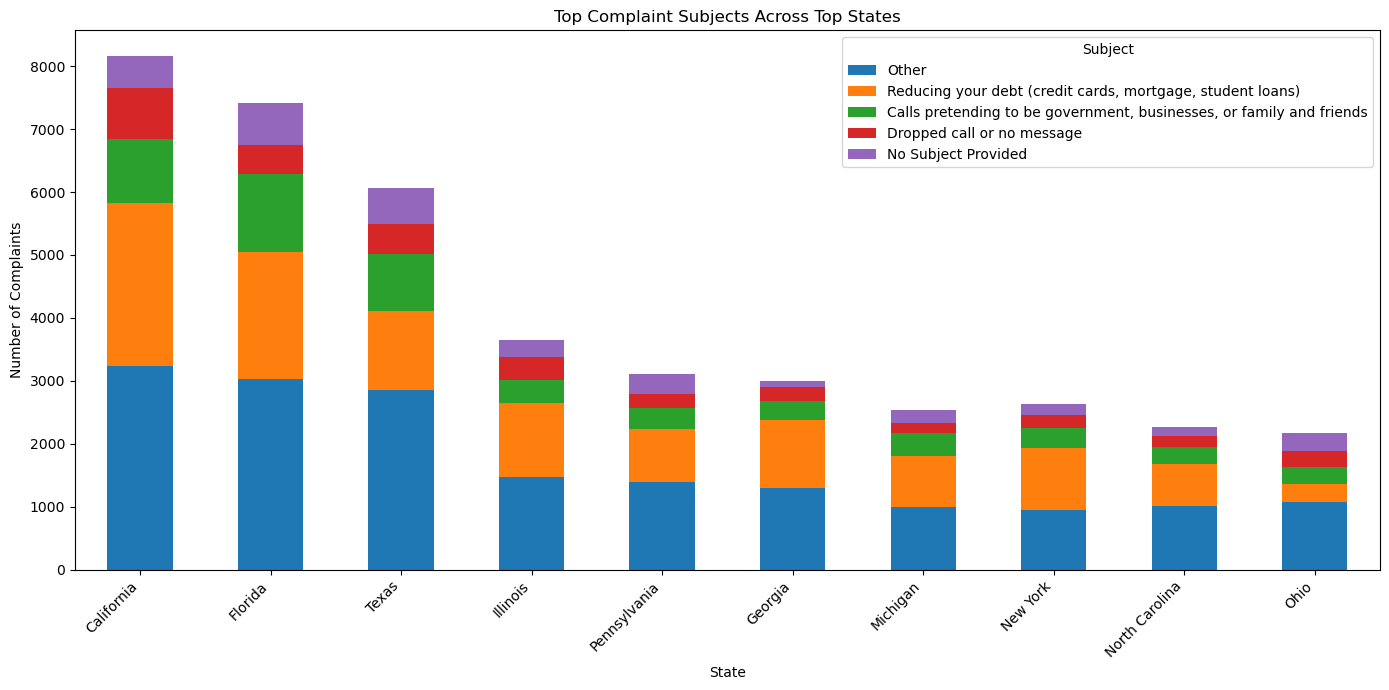

In [179]:
state_subject.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Top Complaint Subjects Across Top States")
plt.xlabel("State")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Reporting-Delay Quality Review

**Analysis objective:** quantify negative delays / invalid date order records before restricting delay analysis to valid non-negative observations.


In [181]:
negative_delay_count = (
    cleaned_dataset["Reporting_Delay_Days"] < 0
).sum()

invalid_date_count = (
    cleaned_dataset["Invalid_Date_Order"] == True
).sum()

print("Negative Reporting Delays:", negative_delay_count)
print("Invalid Date Order Records:", invalid_date_count)

Negative Reporting Delays: 3864
Invalid Date Order Records: 3864


### Valid Reporting Delays

**Analysis objective:** Describe the reporting delay distribution after excluding impossible negative-delay records from the delay-specific analysis.


In [183]:
valid_delay = cleaned_dataset[
    cleaned_dataset["Reporting_Delay_Days"] >= 0
].copy()

print(
    valid_delay["Reporting_Delay_Days"].describe()
)

count    80814.000000
mean         4.999245
std         85.886359
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       8332.000000
Name: Reporting_Delay_Days, dtype: float64


### Distribution of Valid Reporting Delay

**Analysis objective:** Analyze the number of days between Violation_Date and Created_Date using only non-negative delays to understand reporting timing.


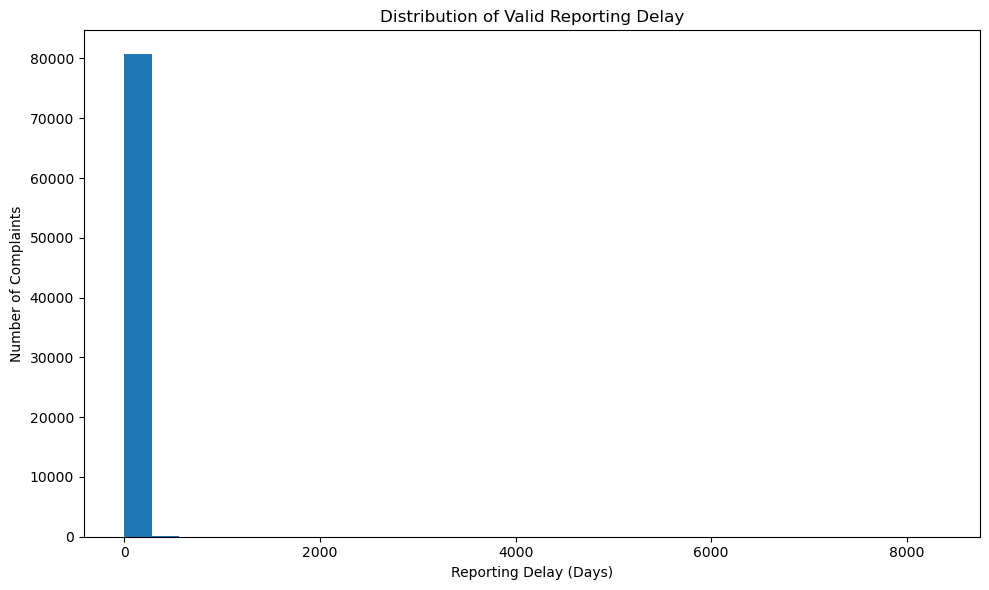

In [185]:
plt.figure(figsize=(10, 6))

plt.hist(
    valid_delay["Reporting_Delay_Days"],
    bins=30
)

plt.title("Distribution of Valid Reporting Delay")
plt.xlabel("Reporting Delay (Days)")
plt.ylabel("Number of Complaints")

plt.tight_layout()
plt.show()

### Reporting-Delay Summary

**Analysis objective:** Summarize mean, median, minimum, and maximum valid reporting delays for interpretation.


In [187]:
delay_summary = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Days": [
        valid_delay["Reporting_Delay_Days"].mean(),
        valid_delay["Reporting_Delay_Days"].median(),
        valid_delay["Reporting_Delay_Days"].min(),
        valid_delay["Reporting_Delay_Days"].max()
    ]
})

delay_summary

,Metric,Days
0,Mean,4.999245
1,Median,0.000000
2,Minimum,0.000000
3,Maximum,8332.000000


### Recent vs Previous Period Definition

**Analysis objective:** Define the comparison windows used to identify emerging complaint subjects, states, and originating numbers.


In [189]:
unique_dates = sorted(
    cleaned_dataset["Created_Date"]
    .dt.normalize()
    .dropna()
    .unique()
)

previous_period = unique_dates[-6:-3]
recent_period = unique_dates[-3:]

print("Previous Period:")
print(previous_period)

print("\nRecent Period:")
print(recent_period)

Previous Period:
[Timestamp('2026-09-04 00:00:00'), Timestamp('2026-09-05 00:00:00'), Timestamp('2026-09-06 00:00:00')]

Recent Period:
[Timestamp('2026-09-07 00:00:00'), Timestamp('2026-09-08 00:00:00'), Timestamp('2026-09-09 00:00:00')]


### Recent and Previous Data Slices

**Analysis objective:** Separate the cleaned records into the selected comparison periods before calculating changes.


In [191]:
previous_data = cleaned_dataset[
    cleaned_dataset["Created_Date"]
    .dt.normalize()
    .isin(previous_period)
]

recent_data = cleaned_dataset[
    cleaned_dataset["Created_Date"]
    .dt.normalize()
    .isin(recent_period)
]

### Emerging Subjects

**Analysis objective:** compare recent subject volume with the previous period to identify subjects with increasing complaint activity.


In [193]:
previous_subject = previous_data["Subject"].value_counts()

recent_subject = recent_data["Subject"].value_counts()

emerging_subjects = pd.DataFrame({
    "Previous_Count": previous_subject,
    "Recent_Count": recent_subject
}).fillna(0)

emerging_subjects["Absolute_Change"] = (
    emerging_subjects["Recent_Count"]
    - emerging_subjects["Previous_Count"]
)

emerging_subjects["Percentage_Change"] = np.where(
    emerging_subjects["Previous_Count"] > 0,
    (
        emerging_subjects["Absolute_Change"]
        / emerging_subjects["Previous_Count"]
    ) * 100,
    np.nan
)

emerging_subjects = emerging_subjects[
    (emerging_subjects["Previous_Count"] >= 50) &
    (emerging_subjects["Recent_Count"] >= 50)
]

emerging_subjects = emerging_subjects.sort_values(
    "Absolute_Change",
    ascending=False
)

emerging_subjects

,Previous_Count,Recent_Count,Absolute_Change,Percentage_Change
Subject,,,,
Other,6125,9178,3053,49.844898
"Reducing your debt (credit cards, mortgage, student loans)",4156,6437,2281,54.884504
"Calls pretending to be government, businesses, or family and friends",1814,2677,863,47.574421
Dropped call or no message,1186,1758,572,48.229342
Medical & prescriptions,1012,1466,454,44.861660
No Subject Provided,1097,1469,372,33.910665
Warranties & protection plans,170,308,138,81.176471
Home improvement & cleaning,170,293,123,72.352941
"Energy, solar, & utilities",60,134,74,123.333333


### Emerging States

**Analysis objective:** compare recent and previous complaint volume by state to identify locations showing increased activity.


In [195]:
previous_state = previous_data[
    previous_data["Consumer_State"] != "Not_Reported"
]["Consumer_State"].value_counts()

recent_state = recent_data[
    recent_data["Consumer_State"] != "Not_Reported"
]["Consumer_State"].value_counts()

emerging_states = pd.DataFrame({
    "Previous_Count": previous_state,
    "Recent_Count": recent_state
}).fillna(0)

emerging_states["Absolute_Change"] = (
    emerging_states["Recent_Count"]
    - emerging_states["Previous_Count"]
)

emerging_states["Percentage_Change"] = np.where(
    emerging_states["Previous_Count"] > 0,
    (
        emerging_states["Absolute_Change"]
        / emerging_states["Previous_Count"]
    ) * 100,
    np.nan
)

emerging_states = emerging_states[
    (emerging_states["Previous_Count"] >= 50) &
    (emerging_states["Recent_Count"] >= 50)
]

emerging_states = emerging_states.sort_values(
    "Absolute_Change",
    ascending=False
)

emerging_states.head(15)

,Previous_Count,Recent_Count,Absolute_Change,Percentage_Change
Consumer_State,,,,
California,1553,2751,1198,77.141017
Texas,1256,1946,690,54.936306
Florida,1698,2321,623,36.690224
Illinois,626,1135,509,81.309904
Virginia,405,800,395,97.530864
Arizona,477,864,387,81.132075
Pennsylvania,601,960,359,59.733777
North Carolina,490,768,278,56.734694
Michigan,548,824,276,50.364964


### Emerging Phone Numbers

**Analysis objective:** compare recent and previous complaint reports for originating numbers to identify recurring numbers with growing activity. These are signals for further review, not proof of fraud.


In [197]:
previous_phone = previous_data[
    previous_data["Company_Phone_Number"] != "Not_Reported"
]["Company_Phone_Number"].value_counts()

recent_phone = recent_data[
    recent_data["Company_Phone_Number"] != "Not_Reported"
]["Company_Phone_Number"].value_counts()

emerging_phones = pd.DataFrame({
    "Previous_Count": previous_phone,
    "Recent_Count": recent_phone
}).fillna(0)

emerging_phones["Absolute_Change"] = (
    emerging_phones["Recent_Count"]
    - emerging_phones["Previous_Count"]
)

emerging_phones["Percentage_Change"] = np.where(
    emerging_phones["Previous_Count"] > 0,
    (
        emerging_phones["Absolute_Change"]
        / emerging_phones["Previous_Count"]
    ) * 100,
    np.nan
)

emerging_phones = emerging_phones[
    (emerging_phones["Recent_Count"] >= 5)
]

emerging_phones = emerging_phones.sort_values(
    ["Absolute_Change", "Recent_Count"],
    ascending=False
)

emerging_phones.head(20)

,Previous_Count,Recent_Count,Absolute_Change,Percentage_Change
Company_Phone_Number,,,,
8336625743,0,94,94,NaN
8402637620,0,84,84,NaN
8775781816,0,79,79,NaN
8445023058,0,78,78,NaN
3213958702,8,66,58,725.0
2178349517,0,55,55,NaN
8559942101,0,49,49,NaN
2178349513,0,38,38,NaN
8663983150,0,25,25,NaN


### State × Subject × Robocall Pattern Analysis

**Analysis objective:** combine geography, complaint subject, and robocall status to identify multi-dimensional complaint patterns.


In [199]:
pattern_analysis = (
    cleaned_dataset
    .groupby(
        [
            "Consumer_State",
            "Subject",
            "Recorded_Message_Or_Robocall"
        ]
    )
    .size()
    .reset_index(name="Complaint_Count")
    .sort_values(
        "Complaint_Count",
        ascending=False
    )
)

pattern_analysis.head(30)

,Consumer_State,Subject,Recorded_Message_Or_Robocall,Complaint_Count
146,California,"Reducing your debt (credit cards, mortgage, st...",Y,2292
286,Florida,Other,Y,2164
143,California,Other,Y,1940
1339,Texas,Other,Y,1924
289,Florida,"Reducing your debt (credit cards, mortgage, st...",Y,1781
141,California,Other,N,1128
1342,Texas,"Reducing your debt (credit cards, mortgage, st...",Y,1122
399,Illinois,Other,Y,1096
402,Illinois,"Reducing your debt (credit cards, mortgage, st...",Y,1079
324,Georgia,"Reducing your debt (credit cards, mortgage, st...",Y,991


### KPI Summary

**Analysis objective:** consolidate the main EDA measures into one summary table for reporting and dashboard reference.


In [201]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Complaints",
        "Unique Subjects",
        "Unique States",
        "Unique Cities",
        "Distinct Reported Phone Numbers",
        "Robocall Reports",
        "Repeated Phone Numbers"
    ],
    "Value": [
        len(cleaned_dataset),
        cleaned_dataset["Subject"].nunique(),
        cleaned_dataset[
            cleaned_dataset["Consumer_State"] != "Not_Reported"
        ]["Consumer_State"].nunique(),
        cleaned_dataset[
            cleaned_dataset["Consumer_City"] != "Not_Reported"
        ]["Consumer_City"].nunique(),
        len(phone_counts),
        (cleaned_dataset["Recorded_Message_Or_Robocall"] == "Y").sum(),
        (phone_counts > 1).sum()
    ]
})

kpi_summary

,Metric,Value
0,Total Complaints,84678
1,Unique Subjects,15
2,Unique States,57
3,Unique Cities,5865
4,Distinct Reported Phone Numbers,70265
5,Robocall Reports,59405
6,Repeated Phone Numbers,4767


# 5) Interactive Dashboard

### Workflow
Reuse the same cleaned dataset and EDA aggregations → prepare dashboard metrics → build independent Plotly figures → export them into a responsive HTML dashboard.

The dashboard does not re-clean or re-load the processed dataset. It uses the cleaned data already prepared in the previous stages, while keeping the original dashboard output path.


In [203]:
# Workflow: Load Plotly/dashboard-specific libraries once for the final presentation layer.
import textwrap
from pathlib import Path

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio


In [204]:
# Dashboard aggregations

total_complaints = len(cleaned_dataset)

robocall_reports = int(
    (cleaned_dataset["Recorded_Message_Or_Robocall"] == "Y").sum()
)

reported_phone_numbers = int(
    cleaned_dataset.loc[
        cleaned_dataset["Company_Phone_Number"] != "Not_Reported",
        "Company_Phone_Number"
    ].nunique()
)

repeated_numbers = int(
    (
        cleaned_dataset.loc[
            cleaned_dataset["Company_Phone_Number"] != "Not_Reported",
            "Company_Phone_Number"
        ]
        .value_counts() > 1
    ).sum()
)

unique_subjects = int(
    cleaned_dataset["Subject"].nunique()
)

unique_states = int(
    cleaned_dataset.loc[
        cleaned_dataset["Consumer_State"] != "Not_Reported",
        "Consumer_State"
    ].nunique()
)

daily = (
    cleaned_dataset
    .groupby(cleaned_dataset["Created_Date"].dt.date)
    .size()
    .sort_index()
)

subject_counts = cleaned_dataset["Subject"].value_counts()

robocall_counts = (
    cleaned_dataset["Recorded_Message_Or_Robocall"]
    .value_counts()
    .reindex(["Y", "N", "Not_Reported"], fill_value=0)
)

state_counts = (
    cleaned_dataset.loc[
        cleaned_dataset["Consumer_State"] != "Not_Reported",
        "Consumer_State"
    ]
    .value_counts()
)

city_counts = (
    cleaned_dataset.loc[
        cleaned_dataset["Consumer_City"] != "Not_Reported",
        "Consumer_City"
    ]
    .value_counts()
)

area_code_counts = (
    cleaned_dataset.loc[
        cleaned_dataset["Consumer_Area_Code"] != "Not_Reported",
        "Consumer_Area_Code"
    ]
    .value_counts()
)

phone_counts = (
    cleaned_dataset.loc[
        cleaned_dataset["Company_Phone_Number"] != "Not_Reported",
        "Company_Phone_Number"
    ]
    .value_counts()
)

# Emerging patterns: last 3 available Created_Date dates vs previous 3.
dates = sorted(
    cleaned_dataset["Created_Date"]
    .dt.normalize()
    .dropna()
    .unique()
)

if len(dates) >= 6:
    previous_period = dates[-6:-3]
    recent_period = dates[-3:]
else:
    split = max(1, len(dates) // 2)
    previous_period = dates[:split]
    recent_period = dates[split:]

previous_data = cleaned_dataset[
    cleaned_dataset["Created_Date"].dt.normalize().isin(previous_period)
]

recent_data = cleaned_dataset[
    cleaned_dataset["Created_Date"].dt.normalize().isin(recent_period)
]

def emerging_table(column, exclude_value="Not_Reported",
                   min_previous=0, min_recent=1):
    prev = previous_data.loc[
        previous_data[column] != exclude_value, column
    ].value_counts()

    recent = recent_data.loc[
        recent_data[column] != exclude_value, column
    ].value_counts()

    out = pd.DataFrame({
        "Previous": prev,
        "Recent": recent
    }).fillna(0)

    out["Change"] = out["Recent"] - out["Previous"]

    out["Change_Pct"] = np.where(
        out["Previous"] > 0,
        (out["Change"] / out["Previous"]) * 100,
        np.nan
    )

    out = out[
        (out["Previous"] >= min_previous) &
        (out["Recent"] >= min_recent)
    ]

    return out.sort_values(
        ["Change", "Recent"],
        ascending=False
    )

emerging_subjects = emerging_table(
    "Subject",
    min_previous=50,
    min_recent=50
)

emerging_states = emerging_table(
    "Consumer_State",
    min_previous=50,
    min_recent=50
)

emerging_phones = emerging_table(
    "Company_Phone_Number",
    min_recent=5
)

print("Dashboard data prepared.")


Dashboard data prepared.


In [205]:
# Helper functions for a clean dashboard

def short_label(value, width=24):
    return textwrap.shorten(
        str(value),
        width=width,
        placeholder="..."
    )

def base_layout(fig, height=420):
    fig.update_layout(
        template="plotly_white",
        height=height,
        margin=dict(l=70, r=30, t=55, b=55),
        font=dict(size=11),
        paper_bgcolor="white",
        plot_bgcolor="white",
        hoverlabel=dict(align="left")
    )
    return fig

def apply_horizontal_style(fig):
    fig.update_xaxes(showgrid=True, automargin=True)
    fig.update_yaxes(
        showgrid=False,
        automargin=True,
        tickfont=dict(size=10)
    )
    return fig


In [206]:
# Build Plotly figures

# 1. Daily complaints
fig_daily = go.Figure(
    go.Scatter(
        x=list(daily.index),
        y=list(daily.values),
        mode="lines+markers",
        hovertemplate=(
            "Date: %{x}<br>"
            "Complaints: %{y:,}<extra></extra>"
        ),
        name="Complaints"
    )
)

fig_daily.update_layout(
    title="Daily Complaint Volume",
    xaxis=dict(
        title="Created Date",
        rangeslider=dict(visible=True),
        automargin=True
    ),
    yaxis=dict(
        title="Complaints",
        automargin=True
    )
)
base_layout(fig_daily, 450)


# 2. Top subjects
top_subjects = subject_counts.head(10).sort_values()

fig_subjects = go.Figure(
    go.Bar(
        x=top_subjects.values,
        y=[short_label(x, 24) for x in top_subjects.index],
        customdata=top_subjects.index,
        orientation="h",
        hovertemplate=(
            "Subject: %{customdata}<br>"
            "Complaints: %{x:,}<extra></extra>"
        )
    )
)

fig_subjects.update_layout(
    title="Top Complaint Subjects",
    xaxis_title="Complaints"
)

base_layout(fig_subjects)
apply_horizontal_style(fig_subjects)
fig_subjects.update_yaxes(autorange="reversed")


# 3. Robocall
fig_robocall = go.Figure(
    go.Pie(
        labels=["Y", "N", "Not Reported"],
        values=robocall_counts.values,
        hole=0.50,
        textinfo="label+percent",
        hovertemplate=(
            "Status: %{label}<br>"
            "Complaints: %{value:,}<br>"
            "Share: %{percent}<extra></extra>"
        )
    )
)

fig_robocall.update_layout(
    title="Robocall Status",
    showlegend=False
)

base_layout(fig_robocall)


# 4. Geography with a simple dropdown
top_states = state_counts.head(10).sort_values()
top_cities = city_counts.head(10).sort_values()
top_area_codes = area_code_counts.head(10).sort_values()

fig_geo = go.Figure()

fig_geo.add_trace(
    go.Bar(
        x=top_states.values,
        y=top_states.index,
        orientation="h",
        visible=True,
        name="State",
        hovertemplate=(
            "State: %{y}<br>"
            "Complaints: %{x:,}<extra></extra>"
        )
    )
)

fig_geo.add_trace(
    go.Bar(
        x=top_cities.values,
        y=top_cities.index,
        orientation="h",
        visible=False,
        name="City",
        hovertemplate=(
            "City: %{y}<br>"
            "Complaints: %{x:,}<extra></extra>"
        )
    )
)

fig_geo.add_trace(
    go.Bar(
        x=top_area_codes.values,
        y=[str(x) for x in top_area_codes.index],
        orientation="h",
        visible=False,
        name="Area Code",
        hovertemplate=(
            "Area Code: %{y}<br>"
            "Complaints: %{x:,}<extra></extra>"
        )
    )
)

fig_geo.update_layout(
    title="Geographic Concentration",
    xaxis_title="Complaints",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=1,
            xanchor="right",
            y=1.16,
            buttons=[
                dict(
                    label="State",
                    method="update",
                    args=[
                        {"visible": [True, False, False]},
                        {"title": "Top States"}
                    ]
                ),
                dict(
                    label="City",
                    method="update",
                    args=[
                        {"visible": [False, True, False]},
                        {"title": "Top Cities"}
                    ]
                ),
                dict(
                    label="Area Code",
                    method="update",
                    args=[
                        {"visible": [False, False, True]},
                        {"title": "Top Area Codes"}
                    ]
                )
            ]
        )
    ]
)

base_layout(fig_geo)
apply_horizontal_style(fig_geo)
fig_geo.update_yaxes(autorange="reversed")


# 5. Frequently reported numbers
top_phones = phone_counts.head(10).sort_values()

fig_phones = go.Figure(
    go.Bar(
        x=top_phones.values,
        y=[str(x) for x in top_phones.index],
        orientation="h",
        hovertemplate=(
            "Phone: %{y}<br>"
            "Reports: %{x:,}<extra></extra>"
        )
    )
)

fig_phones.update_layout(
    title="Frequently Reported Numbers",
    xaxis_title="Complaint Reports"
)

base_layout(fig_phones)
apply_horizontal_style(fig_phones)
fig_phones.update_yaxes(autorange="reversed")


# 6. Emerging subjects
es = emerging_subjects.head(8).sort_values("Change")

fig_es = go.Figure(
    go.Bar(
        x=es["Change"],
        y=[short_label(x, 24) for x in es.index],
        customdata=np.array([
            [
                str(x),
                int(es.loc[x, "Previous"]),
                int(es.loc[x, "Recent"])
            ]
            for x in es.index
        ], dtype=object),
        orientation="h",
        hovertemplate=(
            "Subject: %{customdata[0]}<br>"
            "Previous: %{customdata[1]:,}<br>"
            "Recent: %{customdata[2]:,}<br>"
            "Change: %{x:,}<extra></extra>"
        )
    )
)

fig_es.update_layout(
    title="Emerging Subjects",
    xaxis_title="Change in Complaints"
)

base_layout(fig_es)
apply_horizontal_style(fig_es)
fig_es.update_yaxes(autorange="reversed")


# 7. Emerging states
est = emerging_states.head(8).sort_values("Change")

fig_est = go.Figure(
    go.Bar(
        x=est["Change"],
        y=est.index,
        orientation="h",
        hovertemplate=(
            "State: %{y}<br>"
            "Change: %{x:,}<extra></extra>"
        )
    )
)

fig_est.update_layout(
    title="Emerging States",
    xaxis_title="Change in Complaints"
)

base_layout(fig_est)
apply_horizontal_style(fig_est)
fig_est.update_yaxes(autorange="reversed")


# 8. Emerging phone numbers
ep = emerging_phones.head(10).sort_values("Change")

fig_ep = go.Figure(
    go.Bar(
        x=ep["Change"],
        y=[str(x) for x in ep.index],
        customdata=np.array([
            [
                str(x),
                int(ep.loc[x, "Previous"]),
                int(ep.loc[x, "Recent"])
            ]
            for x in ep.index
        ], dtype=object),
        orientation="h",
        hovertemplate=(
            "Phone: %{customdata[0]}<br>"
            "Previous: %{customdata[1]:,}<br>"
            "Recent: %{customdata[2]:,}<br>"
            "Change: %{x:,}<extra></extra>"
        )
    )
)

fig_ep.update_layout(
    title="Emerging Phone Numbers",
    xaxis_title="Change in Complaints"
)

base_layout(fig_ep)
apply_horizontal_style(fig_ep)
fig_ep.update_yaxes(autorange="reversed")

print("Plotly figures created.")


Plotly figures created.


In [207]:
# Export a clean, non-overlapping dashboard page

figures = [
    ("daily", fig_daily),
    ("subjects", fig_subjects),
    ("robocall", fig_robocall),
    ("geo", fig_geo),
    ("phones", fig_phones),
    ("emerging-subjects", fig_es),
    ("emerging-states", fig_est),
    ("emerging-phones", fig_ep),
]

kpi_cards = f"""
<div class="kpi-grid">
  <div class="kpi"><div class="label">Total Complaints</div><div class="value">{total_complaints:,}</div></div>
  <div class="kpi"><div class="label">Robocall Reports</div><div class="value">{robocall_reports:,}</div></div>
  <div class="kpi"><div class="label">Reported Numbers</div><div class="value">{reported_phone_numbers:,}</div></div>
  <div class="kpi"><div class="label">Repeated Numbers</div><div class="value">{repeated_numbers:,}</div></div>
  <div class="kpi"><div class="label">Unique Subjects</div><div class="value">{unique_subjects:,}</div></div>
  <div class="kpi"><div class="label">States / Geographies</div><div class="value">{unique_states:,}</div></div>
</div>
"""

chart_blocks = []
for name, figure in figures:
    chart_blocks.append(
        f"""
        <section class="card {name}">
            {pio.to_html(
                figure,
                include_plotlyjs=False,
                full_html=False,
                config={
                    "responsive": True,
                    "displaylogo": False,
                    "modeBarButtonsToRemove": [
                        "lasso2d",
                        "select2d"
                    ]
                }
            )}
        </section>
        """
    )

dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>ScamPulse AI Dashboard</title>

<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>

<style>
* {{
    box-sizing: border-box;
}}

body {{
    margin: 0;
    padding: 24px;
    background: #f4f6f8;
    font-family: Arial, Helvetica, sans-serif;
}}

.dashboard {{
    max-width: 1500px;
    margin: 0 auto;
}}

.header {{
    text-align: center;
    margin-bottom: 24px;
}}

.header h1 {{
    margin: 0;
    font-size: 30px;
}}

.header p {{
    margin: 6px 0 0;
    font-size: 14px;
}}

.kpi-grid {{
    display: grid;
    grid-template-columns: repeat(6, 1fr);
    gap: 14px;
    margin-bottom: 18px;
}}

.kpi {{
    background: white;
    border-radius: 10px;
    padding: 18px 12px;
    text-align: center;
    min-height: 100px;
    display: flex;
    flex-direction: column;
    justify-content: center;
}}

.kpi .label {{
    font-size: 12px;
    margin-bottom: 10px;
}}

.kpi .value {{
    font-size: 25px;
    font-weight: 700;
}}

.card {{
    background: white;
    border-radius: 10px;
    padding: 8px;
    margin-bottom: 16px;
    overflow: hidden;
}}

.daily {{
    width: 100%;
}}

.subjects,
.robocall,
.geo,
.phones {{
    display: inline-block;
    vertical-align: top;
    width: calc(50% - 10px);
}}

.subjects {{
    margin-right: 16px;
}}

.emerging-subjects,
.emerging-states,
.emerging-phones {{
    display: inline-block;
    vertical-align: top;
    width: calc(33.333% - 12px);
}}

.emerging-subjects,
.emerging-states {{
    margin-right: 12px;
}}

@media (max-width: 1100px) {{
    .kpi-grid {{
        grid-template-columns: repeat(3, 1fr);
    }}

    .subjects,
    .robocall,
    .geo,
    .phones {{
        width: 100%;
        margin-right: 0;
    }}

    .emerging-subjects,
    .emerging-states,
    .emerging-phones {{
        width: 100%;
        margin-right: 0;
    }}
}}

@media (max-width: 650px) {{
    body {{
        padding: 10px;
    }}

    .kpi-grid {{
        grid-template-columns: repeat(2, 1fr);
    }}

    .header h1 {{
        font-size: 24px;
    }}
}}
</style>
</head>

<body>
<div class="dashboard">

    <div class="header">
        <h1>SCAMPULSE AI</h1>
        <p>Telecom Scam &amp; Spam Pattern Intelligence</p>
    </div>

    {kpi_cards}

    {"".join(chart_blocks)}

</div>
</body>
</html>
"""

dashboard_output = Path(
    "../visualizations/ScamPulse_AI_Dashboard.html"
)

dashboard_output.parent.mkdir(
    parents=True,
    exist_ok=True
)

dashboard_output.write_text(
    dashboard_html,
    encoding="utf-8"
)

print(f"Dashboard saved to: {dashboard_output.resolve()}")


Dashboard saved to: C:\Users\velav\Downloads\AIML Course\Sprint 1 - ScamPulse_AI\visualizations\ScamPulse_AI_Dashboard.html
